In [1]:
#Essential Methods

import itertools

def normalize_and_compare(s1, s2):
    
    parsed1 = ast.literal_eval(s1)
    parsed2 = ast.literal_eval(s2)
    
    normalized1 = (frozenset(parsed1[0]),) + parsed1[1:]
    normalized2 = (frozenset(parsed2[0]),) + parsed2[1:]
    
    
    return normalized1 == normalized2

def get_subsets(input_set):
    
    subsets = []
    
    for r in range(len(input_set) + 1):
        
        subsets.extend(itertools.combinations(input_set,r))
        
    del subsets[0]    
       
    for i in range(0,len(subsets)):
        
        if len(subsets[i]) != 0:
        
            subsets[i] = set(subsets[i])
        
    return subsets

def subsets_of_subsets(s):
    s = list(s)
    
    def partitions(s):
        if len(s) == 1:
            yield [s]
            return
        first = s[0]
        for smaller in partitions(s[1:]):
            # Add the first element to each of the subpartitions
            for n, subset in enumerate(smaller):
                yield smaller[:n] + [[first] + subset] + smaller[n+1:]
            # Or start a new partition
            yield [[first]] + smaller

    result = []
    for partition in partitions(s):
        # Convert each list into a set for the final output
        result.append([set(subset) for subset in partition])

    return result

In [2]:
from platform import python_version
print(python_version())

3.13.2


In [3]:
#Create System Model under Test
'''
def env(state):
    
    pSwitchesTopology = { 0: [1,2],
                          1: [0,2],
                          2: [0, 1, 3, 4],
                          3: [2, "PS"],
                          4: [2, "PS"]
                        }

    pSwitchPorts = { 0: {0:11, 1:22, 2:1, 3:2},
                     1: {0:33, 1:44 ,2:0, 3:2},
                     2: {0:3, 1:0, 2:1, 3:4, 4:55},
                     #1: {0:33, 1:44, 2:0, 3:2},
                     #2: {0:55, 1:0, 2:1},
                     3: {0:2, 1:"PS"},
                     4: {0:2, 1:"PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:2},
                     66: {0:0}
    }

    neighborsofEachSwitch = { 0: [11, 22, 1, 2],
                              1: [0, 2, 33, 44],
                              2: [0, 1, 3, 4, 55],
                              #1: [33,44,0,2],
                              #2: [55,0,1],
                              3: [2],
                              4: [2], 
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [0]
    }

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 0
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 0}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"]
                            }
                            
    stepsToSwitches = { 11: [1, 2, 2, 3, 3],
                        22: [1, 2, 2, 3, 3],
                        33: [2, 1, 2, 3, 3],
                        44: [2, 1, 2, 3, 3],
                        55: [2, 2, 1, 2, 2],
                        66: [1, 2, 2, 3, 3]
    }

    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0

    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches  
'''

'\ndef env(state):\n    \n    pSwitchesTopology = { 0: [1,2],\n                          1: [0,2],\n                          2: [0, 1, 3, 4],\n                          3: [2, "PS"],\n                          4: [2, "PS"]\n                        }\n\n    pSwitchPorts = { 0: {0:11, 1:22, 2:1, 3:2},\n                     1: {0:33, 1:44 ,2:0, 3:2},\n                     2: {0:3, 1:0, 2:1, 3:4, 4:55},\n                     #1: {0:33, 1:44, 2:0, 3:2},\n                     #2: {0:55, 1:0, 2:1},\n                     3: {0:2, 1:"PS"},\n                     4: {0:2, 1:"PS"},\n                     11: {0:0},\n                     22: {0:0},\n                     33: {0:1},\n                     44: {0:1},\n                     55: {0:2},\n                     66: {0:0}\n    }\n\n    neighborsofEachSwitch = { 0: [11, 22, 1, 2],\n                              1: [0, 2, 33, 44],\n                              2: [0, 1, 3, 4, 55],\n                              #1: [33,44,0,2],\n               

In [4]:
#Create System Model under Test
# Fat Tree Topology
# 3 Layer
'''
def env(state):
    
    pSwitchesTopology = { 0: [4, 5],
                          1: [4, 5],
                          2: [4, 5],
                          3: [4, 5],
                          4: [0, 1, 2, 3, 6],
                          5: [0, 1, 2, 3, 6],
                          6: [4, 5, "PS"]
                        }

    pSwitchPorts = { 0: {0:4, 1:5, 2:11, 3:22},
                     1: {0:4, 1:5 ,2:33, 3:44},
                     2: {0:4, 1:5, 2:55, 3:66},
                     3: {0:4, 1:5, 2:77, 3:88},
                     4: {0:0, 1:1, 2:2, 3:3, 4:6},
                     5: {0:0, 1:1, 2:2, 3:3, 4:6},
                     6: {0:4, 1:5, 2:"PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:2},
                     66: {0:2},
                     77: {0:3},
                     88: {0:3}
    }

    neighborsofEachSwitch = { 0: [11, 22, 4, 5],
                              1: [33, 44, 4, 5],
                              2: [55, 66, 4, 5],
                              3: [77, 88, 4, 5],
                              4: [0, 1, 2, 3, 6], 
                              5: [0, 1, 2, 3, 6],
                              6: [4, 5],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3,
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0:3},
                     88: {0:3}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1,2,2,2,1,1,2],
                        22: [1,2,2,2,1,1,2],
                        33: [2,1,2,2,1,1,2],
                        44: [2,1,2,2,1,1,2],
                        55: [2,2,1,2,1,1,2],
                        66: [2,2,1,2,1,1,2],
                        77: [2,2,2,1,1,1,2],
                        88: [2,2,2,1,1,1,2]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches  
'''

'\ndef env(state):\n    \n    pSwitchesTopology = { 0: [4, 5],\n                          1: [4, 5],\n                          2: [4, 5],\n                          3: [4, 5],\n                          4: [0, 1, 2, 3, 6],\n                          5: [0, 1, 2, 3, 6],\n                          6: [4, 5, "PS"]\n                        }\n\n    pSwitchPorts = { 0: {0:4, 1:5, 2:11, 3:22},\n                     1: {0:4, 1:5 ,2:33, 3:44},\n                     2: {0:4, 1:5, 2:55, 3:66},\n                     3: {0:4, 1:5, 2:77, 3:88},\n                     4: {0:0, 1:1, 2:2, 3:3, 4:6},\n                     5: {0:0, 1:1, 2:2, 3:3, 4:6},\n                     6: {0:4, 1:5, 2:"PS"},\n                     11: {0:0},\n                     22: {0:0},\n                     33: {0:1},\n                     44: {0:1},\n                     55: {0:2},\n                     66: {0:2},\n                     77: {0:3},\n                     88: {0:3}\n    }\n\n    neighborsofEachSwitch = { 0: [11, 2

In [5]:
#Create System Model under Test
#Tree Topology

def env_tree(state):
    
    pSwitchesTopology = { 0: [4],
                          1: [4],
                          2: [5],
                          3: [5],
                          4: [0, 1 , 6],
                          5: [2, 3, 6],
                          6: [4, 5, "PS"]
                        }

    pSwitchPorts = { 0: {0:4, 2:11, 3:22},
                     1: {0:4 ,2:33, 3:44},
                     2: {1:5, 2:55, 3:66},
                     3: {1:5, 2:77, 3:88},
                     4: {0:0, 1:1, 4:6},
                     5: {2:2, 3:3, 4:6},
                     6: {0:4, 1:5, 2:"PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:2},
                     66: {0:2},
                     77: {0:3},
                     88: {0:3}
    }
    
    selectedSwitches = [4, 5, 6, 0, 1, 2, 3]

    clusters = []
    
    cutPorts = { 0: {0:4},
                 1: {0:4 },
                 2: {1:5},
                 3: {1:5},
                 4: {4:6},
                 5: {4:6},
                 6: {2:"PS"},
                 11: {0:0},
                 22: {0:0},
                 33: {0:1},
                 44: {0:1},
                 55: {0:2},
                 66: {0:2},
                 77: {0:3},
                 88: {0:3}
    }

    neighborsofEachSwitch = { 0: [11, 22, 4],
                              1: [33, 44, 4],
                              2: [55, 66, 5],
                              3: [77, 88, 5],
                              4: [0, 1, 6], 
                              5: [2, 3, 6],
                              6: [4, 5],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3]
    }

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0],
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3,
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0:3},
                     88: {0:3}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    stepsToSwitches = { 11: [1,3,5,5,2,4,3],
                        22: [1,3,5,5,2,4,3],
                        33: [3,1,5,5,2,4,3],
                        44: [3,1,5,5,2,4,3],
                        55: [5,5,1,3,4,2,3],
                        66: [5,5,1,3,4,2,3],
                        77: [5,5,3,1,4,2,3],
                        88: [5,5,3,1,4,2,3]
    }
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0

    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters

In [6]:
#Create System Model under Test
#Tree Topology

def env_tree_Three(state):
    
    pSwitchesTopology = { 0: [6],
                          1: [6],
                          2: [7],
                          3: [7],
                          4: [8],
                          5: [8],
                          6: [0, 1, 9],
                          7: [2, 3, 9],
                          8: [4, 5, 9],
                          9: [6, 7, 8, "PS"]
                        }

    pSwitchPorts = { 0: {0:6, 1:11, 2:22},
                     1: {0:6 ,1:33, 2:44},
                     2: {0:7, 1:55, 2:66},
                     3: {0:7, 1:77, 2:88},
                     4: {0:8, 1:99, 2:100},
                     5: {0:8, 1:101, 2:102},
                     6: {0:0, 1:1, 2:9},
                     7: {0:2, 1:3, 2:9},
                     8: {0:4, 1:5, 2: 9},
                     9: {0:6, 1:7, 2:8, 3: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:2},
                     66: {0:2},
                     77: {0:3},
                     88: {0:3},
                     99: {0:4},
                     100: {0:4},
                     101: {0:5},
                     102: {0:5},
    }
    
    selectedSwitches = [6,7,8,9,0,1,2,3,4,5]

    clusters = []
    
    cutPorts = { 0: {0:6},
                 1: {0:6 },
                 2: {0:7},
                 3: {0:7},
                 4: {0:8},
                 5: {0:8},
                 6: {2:9},
                 7: {2:9},
                 8: {2:9},
                 9: {3:"PS"},
                 11: {0:0},
                 22: {0:0},
                 33: {0:1},
                 44: {0:1},
                 55: {0:2},
                 66: {0:2},
                 77: {0:3},
                 88: {0:3},
                 99: {0:4},
                 100: {0:4},
                 101: {0:5},
                 102: {0:5},
    }

    neighborsofEachSwitch = { 0: [11, 22, 6],
                              1: [33, 44, 6],
                              2: [55, 66, 7],
                              3: [77, 88, 7],
                              4: [99, 100, 8],
                              5: [101, 102, 8],
                              6: [0, 1, 9],
                              7: [2, 3, 9],
                              8: [4, 5, 9],
                              9: [5, 5, 9],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3],
                              99: [4],
                              100: [4],
                              101: [5],
                              102: [5]

    }

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0],
                             7: [0],
                             8: [0],
                             9: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3,
                        99: 4,
                        100: 4,
                        101: 5,
                        102: 5
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0:3},
                     88: {0:3},
                     99: {0: 4},
                     100: {0: 4},
                     101: {0:5},
                     102: {0:5}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"],
                              99: ["A8","B8","C8"],
                              100: ["A9","B9","C9"],
                              101: ["A10","B10","C10"],
                              102: ["A11","B11","C11"]
                             
                            }
    stepsToSwitches = { 11: [1, 3, 5, 5, 5, 5, 2, 4, 4, 3],
                        22: [1, 3, 5, 5, 5, 5, 2, 4, 4, 3],
                        33: [3, 1, 5, 5, 5, 5, 2, 4, 4, 3],
                        44: [3, 1, 5, 5, 5, 5, 2, 4, 4, 3],
                        55: [5, 5, 1, 3, 5, 5, 4, 2, 4, 3],
                        66: [5, 5, 1, 3, 5, 5, 4, 2, 4, 3],
                        77: [5, 5, 3, 1, 5, 5, 4, 2, 4, 3],
                        88: [5, 5, 3, 1, 5, 5, 4, 2, 4, 3],
                        99: [5, 5, 5, 5, 1, 3, 4, 4, 2, 3],
                        100: [5, 5, 5, 5, 1, 3, 4, 4, 2, 3],
                        101: [5, 5, 5, 5, 3, 1, 4, 4, 2, 3],
                        102: [5, 5, 5, 5, 3, 1, 4, 4, 2, 3]
                        
    }
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0

    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters

In [7]:
#Create System Model under Test
#Tree Topology

def env_tree_Four(state):
    env_tree_Three
    pSwitchesTopology = { 0: [8],
                          1: [8],
                          2: [9],
                          3: [9],
                          4: [10],
                          5: [10],
                          6: [11],
                          7: [11],
                          8: [0,1,12],
                          9: [2,3,12],
                          10: [4,5,12],
                          11: [6,7,12],
                          12: [8,9,10,11,"PS"]
                        }

    pSwitchPorts = { 0: {0:8, 1:110, 2:220},
                     1: {0:8 ,1:330, 2:440},
                     2: {0:9, 1:550, 2:660},
                     3: {0:9, 1:770, 2:880},
                     4: {0:10, 1:990, 2:1000},
                     5: {0:10, 1:1010, 2:1020},
                     6: {0:11, 1:1030, 2:1040},
                     7: {0:11, 1:1050, 2:1060},
                     8: {0:0, 1:1, 2: 12},
                     9: {0:2, 1:3, 2:12},
                     10: {0:4, 1:5, 2:12},
                     11: {0:6, 1:7, 2:12},
                     12: {0:8, 1: 9, 2: 10, 3:11, 4:"PS"},
                     110: {0:0},
                     220: {0:0},
                     330: {0:1},
                     440: {0:1},
                     550: {0:2},
                     660: {0:2},
                     770: {0:3},
                     880: {0:3},
                     990: {0:4},
                     1000: {0:4},
                     1010: {0:5},
                     1020: {0:5},
                     1030: {0:6},
                     1040: {0:6},
                     1050: {0:7},
                     1060: {0:7},
    }
    
    selectedSwitches = [12, 8, 9, 10, 11, 0, 1, 2, 3, 4, 5, 6, 7]

    clusters = []
    
    cutPorts = { 0: {0:8},
                 1: {0:8},
                 2: {0:9},
                 3: {0:9},
                 4: {0:10},
                 5: {0:10},
                 6: {0:11},
                 7: {0:11},
                 8: {2:12},
                 9: {2: 12},
                 10: {2: 12},
                 11: {2:12},
                 12: {4: "PS"},
                 110: {0:0},
                 220: {0:0},
                 330: {0:1},
                 440: {0:1},
                 550: {0:2},
                 660: {0:2},
                 770: {0:3},
                 880: {0:3},
                 990: {0:4},
                 1000: {0:4},
                 1010: {0:5},
                 1020: {0:5},
                 1030: {0:6},
                 1040: {0:6},
                 1050: {0:7},
                 1060: {0:7},
    }

    neighborsofEachSwitch = { 0: [110, 220, 8],
                              1: [330, 440, 8],
                              2: [550, 660, 9],
                              3: [770, 880, 9],
                              4: [990, 1000, 10], 
                              5: [1010, 1020, 10],
                              6: [1030, 1040, 11],
                              7: [1050, 1060, 11],
                              8: [0, 1, 12],
                              9: [2, 3, 12],
                              10: [4, 5, 12],
                              11: [6, 7, 12],
                              12: [8, 9, 10, 11],
                              110: [0],
                              220: [0],
                              330: [1],
                              440: [1],
                              550: [2],
                              660: [2],
                              770: [3],
                              880: [3],
                              990: [4],
                              1000: [4],
                              1010: [5],
                              1020: [5],
                              1030: [6],
                              1040: [6],
                              1050: [7],
                              1060: [7],

    }

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0],
                             7: [0],
                             8: [0],
                             9: [0],
                             10: [0],
                             11: [0],
                             12: [0]
                           }

    workersTopology = { 110: 0,
                        220: 0,
                        330: 1,
                        440: 1,
                        550: 2,
                        660: 2,
                        770: 3,
                        880: 3,
                        990: 4,
                        1000: 4,
                        1010: 5,
                        1020: 5,
                        1030: 6,
                        1040: 6,
                        1050: 7,
                        1060: 7
                      }

    pWorkerPorts = { 110: {0: 0},
                     220: {0: 0},
                     330: {0: 1},
                     440: {0: 1},
                     550: {0: 2},
                     660: {0: 2},
                     770: {0:3},
                     880: {0:3},
                     990: {0: 4},
                     1000: {0: 4},
                     1010: {0:5},
                     1020: {0:5},
                     1030: {0: 6},
                     1040: {0: 6},
                     1050: {0:7},
                     1060: {0:7}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 110: ["A0","B0","C0"],
                              220: ["A1","B1","C1"],
                              330: ["A2","B2","C2"],
                              440: ["A3","B3","C3"],
                              550: ["A4","B4","C4"],
                              660: ["A5","B5","C5"],
                              770: ["A6","B6","C6"],
                              880: ["A7","B7","C7"],
                              990: ["A8","B8","C8"],
                              1000: ["A9","B9","C9"],
                              1010: ["A10","B10","C10"],
                              1020: ["A11","B11","C11"],
                              1030: ["A12","B12","C12"],
                              1040: ["A13","B13","C13"],
                              1050: ["A14","B14","C14"],
                              1060: ["A15","B15","C15"]
                             
                            }
    stepsToSwitches = { 110: [1, 3, 5, 5, 5, 5, 5, 5, 2, 4, 4, 4, 3],
                        220: [1, 3, 5, 5, 5, 5, 5, 5, 2, 4, 4, 4, 3],
                        330: [3, 1, 5, 5, 5, 5, 5, 5, 2, 4, 4, 4, 3],
                        440: [3, 1, 5, 5, 5, 5, 5, 5, 2, 4, 4, 4, 3],
                        550: [5, 5, 1, 3, 5, 5, 5, 5, 4, 2, 4, 4, 3],
                        660: [5, 5, 1, 3, 5, 5, 5, 5, 4, 2, 4, 4, 3],
                        770: [5, 5, 3, 1, 5, 5, 5, 5, 4, 2, 4, 4, 3],
                        880: [5, 5, 3, 1, 5, 5, 5, 5, 4, 2, 4, 4, 3],
                        990: [5, 5, 5, 5, 1, 3, 5, 5, 4, 4, 2, 4, 4],
                        1000: [5, 5, 5, 5, 1, 3, 5, 5, 4, 4, 2, 4, 4],
                        1010: [5, 5, 5, 5, 3, 1, 5, 5, 4, 4, 2, 4, 3],
                        1020: [5, 5, 5, 5, 3, 1, 5, 5, 4, 4, 2, 4, 3],
                        1030: [5, 5, 5, 5, 5, 5, 1, 3, 4, 4, 4, 2, 3],
                        1040: [5, 5, 5, 5, 5, 5, 1, 3, 4, 4, 4, 2, 3],
                        1050: [5, 5, 5, 5, 5, 5, 3, 1, 4, 4, 4, 2, 3],
                        1060: [5, 5, 5, 5, 5, 5, 3, 1, 4, 4, 4, 2, 3],
                        
    }
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0

    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters

In [8]:
#Create System Model under Test
# Fat Tree Topology
# 3 Cluster

def env_3Clusters(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 12, 13, 14],
                          3: [0, 1, 12, 13, 14],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5, 12, 13, 14],
                          7: [4, 5, 12, 13, 14],
                          8: [10, 11],
                          9: [10, 11],
                          10: [8 , 9, 12, 13, 14],
                          11: [8, 9, 12, 13, 14],
                          12: [2, 6, 10, "PS", 3, 7, 11],
                          13: [2, 6, 10, "PS", 3, 7, 11],
                          14: [2, 6, 10, "PS", 3, 7, 11]
                        }

    pSwitchPorts = { 0: {0: 111, 1: 222, 2: 3, 3: 2},
                     1: {1: 3, 2: 2 ,3:333, 4:444},
                     2: {0: 0, 1: 1, 2: 14, 3: 13, 4: 12},
                     3: {0: 1, 1: 0, 2: 12, 3: 13, 4: 14},
                     4: {1: 7, 2: 6, 0: 555, 3: 666},
                     5: {1: 7, 2: 6, 0: 777, 3: 888},
                     6: {0: 4, 1: 5, 2: 14, 3: 13, 4: 12},
                     7: {0: 5, 1: 4, 2: 12, 3: 13, 4:14},
                     8: {0: 999, 1: 1111, 1: 11, 2: 10},
                     9: {0:2222, 1: 3333, 2: 11, 3: 10},
                     10: {0: 8, 1: 9, 2: 14, 3: 13, 4: 12},
                     11: {0: 9, 1: 8, 2: 12, 3: 13, 4: 14},
                     12: {0: 2, 1: 6, 2: 10, 3: "PS", 4: 3, 5:7, 6: 11},
                     13: {0: 6, 1: 10, 2: "PS", 3: 2, 4: 3, 5: 7, 6: 11},
                     14: {0: 10, 1: "PS", 2: 2, 3: 6, 4: 3, 5: 7, 6: 11},
                     111: {0:0},
                     222: {0:0},
                     333: {0:1},
                     444: {0:1},
                     555: {0:4},
                     666: {0:4},
                     777: {0:5},
                     888: {0:5},
                     999: {0:8},
                     1111: {0:8},
                     2222: {0:9},
                     3333: {0:9}
    }

    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7],
                 2: [8, 9, 10, 11]}

    selectedSwitches = [14, 13, 12, 11, 10, 7, 6, 2, 3, 9, 0, 1, 5, 4, 8]
    
    cutPorts = {     0: {3: 2},
                     1: {2: 2},
                     2: {4: 12},
                     3: {},
                     4: {2: 6},
                     5: {2: 6},
                     6: {3: 13},
                     7: {},
                     8: {2: 10},
                     9: {3: 10},
                     10: {2: 14},
                     11: {},
                     12: {3: "PS"},
                     13: {2: "PS"},
                     14: {1: "PS"},
                     111: {0:0},
                     222: {0:0},
                     333: {0:1},
                     444: {0:1},
                     555: {0:4},
                     666: {0:4},
                     777: {0:5},
                     888: {0:5},
                     999: {0:8},
                     1111: {0:8},
                     2222: {0:9},
                     3333: {0:9}
    }

    neighborsofEachSwitch = { 0: [111, 222, 2, 3],
                              1: [333, 444, 2, 3],
                              2: [0, 1, 12, 13, 14],
                              3: [0, 1],
                              4: [555, 666, 6, 7], 
                              5: [777, 888, 6, 7],
                              6: [4, 5, 12, 13, 14],
                              7: [4, 5],
                              8: [999, 1111, 10, 11],
                              9: [2222, 3333, 10, 11],
                              10: [8 , 9, 12, 13, 14],
                              11: [8, 9],
                              12: [2, 6, 10],
                              13: [2, 6, 10],
                              14: [2, 6, 10],
                              111: [0],
                              222: [0],
                              333: [1],
                              444: [1],
                              555: [4],
                              666: [4],
                              777: [5],
                              888: [5],
                              999: [8],
                              1111:[8],
                              2222:[9],
                              3333:[9]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [], 
                             0: [0],
                             1: [0],
                             2: [],
                             #2: [0],
                             3: [], 
                            #3: [0],
                             4: [],
                             #4: [0],
                             5: [0],
                             #6: [0], 
                             6: [],
                             7: [0],
                             8: [0],
                             #8: [0],
                             9: [0],
                             10: [],
                             #10: [0],
                             11: [0],
                             12: [],
                             #12: [0],
                             13: [0],
                             14: [],
                             #14: [0]
                           }

    workersTopology = { 111: 0,
                        222: 0,
                        333: 1,
                        444: 1,
                        555: 4,
                        666: 4,
                        777: 5,
                        888: 5,
                        999: 8,
                        1111:8,
                        2222:9,
                        3333:9
                      }

    pWorkerPorts = { 111: {0:0},
                     222: {0:0},
                     333: {0:1},
                     444: {0:1},
                     555: {0:4},
                     666: {0:4},
                     777: {0:5},
                     888: {0:5},
                     999: {0:8},
                     1111: {0:8},
                     2222: {0:9},
                     3333: {0:9}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 111: ["A0","B0","C0"],
                              222: ["A1","B1","C1"],
                              333: ["A2","B2","C2"],
                              444: ["A3","B3","C3"],
                              555: ["A4","B4","C4"],
                              666: ["A5","B5","C5"],
                              777: ["A6","B6","C6"],
                              888: ["A7","B7","C7"],
                              999: ["A8","B8","C8"],
                              1111:["A9","B9","C9"],
                              2222:["A10","B10","C10"],
                              3333:["A11","B11","C11"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 111: [1, 3, 2, 2, 5, 5, 4, 6, 5, 5, 4, 6, 3, 3, 3],
                        222: [1, 3, 2, 2, 5, 5, 4, 6, 5, 5, 4, 6, 3, 3, 3],
                        333: [3, 1, 2, 2, 5, 5, 4, 4, 5, 5, 4, 6, 3, 3, 3],
                        444: [3, 1, 2, 2, 5, 5, 4, 4, 5, 5, 4, 6, 3, 3, 3],
                        555: [5, 5, 4, 6, 1, 3, 2, 2, 5, 5, 4, 6, 3, 3, 3],
                        666: [5, 5, 4, 6, 1, 3, 2, 2, 5, 5, 4, 6, 3, 3, 3],
                        777: [5, 5, 4, 6, 3, 1, 2, 2, 5, 5, 4, 6, 3, 3, 3],
                        888: [5, 5, 4, 6, 3, 1, 2, 2, 5, 5, 4, 6, 3, 3, 3],
                        999: [5, 5, 4, 6, 5, 5, 4, 6, 1, 2, 2, 2, 3, 3, 3],
                        1111: [5, 5, 4, 6, 5, 5, 4, 6, 1, 2, 2, 2, 3, 3, 3],
                        2222: [5, 5, 4, 6, 5, 5, 4, 6, 3, 1, 2, 2, 3, 3, 3],
                        3333: [5, 5, 4, 6, 5, 5, 4, 6, 3, 1, 2, 2, 3, 3, 3] 
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [9]:
#Create System Model under Test
# Fat Tree Topology
# 2 Cluster

def env_2Clusters(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3}, 
                     1: {0: 33, 1: 44, 2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {0: 55, 1: 66, 2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [55, 66, 6, 7], 
                              5: [77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [4],
                              66: [4],
                              77: [5],
                              88: [5]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [], 
                            #2: [0],
                             3: [0],
                             4: [], 
                            #4: [0],
                             5: [0],
                             #6: [0],
                             6: [],
                             #7: [0],
                             7: [],
                             8: [0],
                             #9: [0]
                             9: []
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 4,
                        66: 4,
                        77: 5,
                        88: 5,
                      }

    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 4},
                     66: {0: 4},
                     77: {0: 5},
                     88: {0: 5}
    }

    workersNumber = len(workersTopology)
    
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [10]:

#Create System Model under Test
# Fat Tree Topology
# 2 Cluster

def env_2Clusters_Percentages(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3}, 
                     1: {0: 33, 1: 44, 2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {0: 55, 1: 66, 2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [55, 66, 6, 7], 
                              5: [77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [4],
                              66: [4],
                              77: [5],
                              88: [5]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0], 
                             2: [0],
                             3: [0], 
                             4: [0],
                             5: [0],
                             6: [0], 
                             7: [0],
                             8: [0],
                             9: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 4,
                        66: 4,
                        77: 5,
                        88: 5,
                      }

    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 4},
                     66: {0: 4},
                     77: {0: 5},
                     88: {0: 5}
    }

    workersNumber = len(workersTopology)
    
    fragmentsofEachWorker = { 11: ["A0", "B0", "C0", "D0", "E0", "F0"],
                              22: ["A1", "B1", "C1", "D1", "E1", "F1"],
                              33: ["A2", "B2", "C2", "D2", "E2", "F2"],
                              44: ["A3", "B3", "C3", "D3", "E3", "F3"],
                              55: ["A4", "B4", "C4", "D4", "E4", "F4"],
                              66: ["A5", "B5", "C5", "D5", "E5", "F5"],
                              77: ["A6", "B6", "C6", "D6", "E6", "F6"],
                              88: ["A7", "B7", "C7", "D7", "E7", "F7"]
                            }
    
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [11]:

#Create System Model under Test
# Fat Tree Topology
# 2 Cluster

def env_2Clusters_Percentages_2(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3}, 
                     1: {0: 33, 1: 44, 2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {0: 55, 1: 66, 2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [55, 66, 6, 7], 
                              5: [77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [4],
                              66: [4],
                              77: [5],
                              88: [5]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0,1],
                             1: [0,1], 
                             2: [0,1],
                             3: [0,1], 
                             4: [0,1],
                             5: [0,1],
                             6: [0,1], 
                             7: [0,1],
                             8: [0,1],
                             9: [0,1]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 4,
                        66: 4,
                        77: 5,
                        88: 5,
                      }

    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 4},
                     66: {0: 4},
                     77: {0: 5},
                     88: {0: 5}
    }

    workersNumber = len(workersTopology)
    
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    
    
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [12]:
#Create System Model under Test
# Fat Tree Topology
# 2 Cluster
'''
def env_2Clusters(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3}, 
                     1: {0: 33, 1: 44, 2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9, 4: 99, 5: 111}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {0: 55, 1: 66, 2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     #7: {0: 4, 1: 5, 2: 8, 3: 9, 4: 222, 5: 333}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5},
                     99: {0: 2},
                     111: {0: 2},
                     #222: {0: 7},
                     #333 : {0: 7}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5},
                     99: {0: 2},
                     111: {0: 2},
                     #222: {0: 7},
                     #333 : {0: 7}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [0, 1, 8, 9, 99, 111],
                              3: [0, 1, 8, 9],
                              4: [55, 66, 6, 7], 
                              5: [77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              #7: [4, 5, 8, 9, 222, 333],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [4],
                              66: [4],
                              77: [5],
                              88: [5],
                              99: [2],
                              111: [2],
                              #222: [7],
                              #333: [7]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0], 
                             7: [0],
                             8: [0],
                             9: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 4,
                        66: 4,
                        77: 5,
                        88: 5,
                        99: 2,
                        111: 2,
                        #222: 7,
                        #333: 7
                      }

    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 4},
                     66: {0: 4},
                     77: {0: 5},
                     88: {0: 5},
                     99: {0: 2},
                     111: {0: 2},
                     #222: {0: 7},
                     #333 : {0: 7}
    }

    workersNumber = len(workersTopology)
    
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"],
                              99: ["A8","B8","C8"],
                              111: ["A9","B9","C9"],
                              #222: ["A10","B10"],
                              #333: ["A11","B11"]
                            }
  
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        99: [2, 2, 1, 3, 4, 4, 3, 5, 2, 2],
                        111: [2, 2, 1, 3, 4, 4, 3, 3, 2, 2],
                        #222: [4, 4, 3, 3, 2, 2, 3, 1, 2, 2],
                        #333: [4, 4, 3, 3, 2, 2, 3, 1, 2, 2]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  
'''

'\ndef env_2Clusters(state):\n    \n    pSwitchesTopology = { 0: [2, 3],\n                          1: [2, 3],\n                          2: [0, 1, 8, 9],\n                          3: [0, 1],\n                          4: [6, 7],\n                          5: [6, 7],\n                          6: [4, 5],\n                          7: [4, 5, 8, 9],\n                          8: [2, 7, "PS"],\n                          9: [2, 7, "PS"]\n                        }\n\n    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3}, \n                     1: {0: 33, 1: 44, 2: 2, 3: 3}, \n                     2: {0: 0, 1: 1, 2: 8, 3: 9, 4: 99, 5: 111}, \n                     3: {0: 0, 1: 1, 2: 8, 3: 9}, \n                     4: {0: 55, 1: 66, 2: 6, 3: 7}, \n                     5: {0: 77, 1: 88, 2: 6, 3: 7}, \n                     6: {0: 4, 1: 5, 2:8, 3: 9}, \n                     #7: {0: 4, 1: 5, 2: 8, 3: 9, 4: 222, 5: 333}, \n                     7: {0: 4, 1: 5, 2: 8, 3: 9}, \n                     8: {

In [13]:
#Create System Model under Test
# Fat Tree Topology
# 2 Cluster

def env_2Clusters_Zipf15(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3, 4:33, 5:44}, 
                     1: {2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7, 4:55, 5:66}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:0},
                     22: {0:0},
                     33: {0:0},
                     44: {0:0},
                     55: {0:5},
                     66: {0:5},
                     77: {0:5},
                     88: {0:5}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]
    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:0},
                     44: {0:0},
                     55: {0:5},
                     66: {0:5},
                     77: {0:5},
                     88: {0:5}
    }

    neighborsofEachSwitch = { 0: [11, 22, 33, 44, 2, 3],
                              1: [2, 3],
                              2: [0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [6, 7], 
                              5: [55, 66, 77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [0],
                              44: [0],
                              55: [5],
                              66: [5],
                              77: [5],
                              88: [5]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [], 
                            #2: [0],
                             3: [0],
                             4: [], 
                            #4: [0],
                             5: [0],
                             6: [0], 
                             7: [0],
                             8: [0],
                             #9: [0]
                             9: []
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 0,
                        44: 0,
                        55: 5,
                        66: 5,
                        77: 5,
                        88: 5,
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 5},
                     66: {0: 5},
                     77: {0: 5},
                     88: {0: 5}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [14]:
#Create System Model under Test
# Fat Tree Topology
# 2 Cluster

def env_2Clusters_Zipf2(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {2: 2, 3: 3}, 
                     1: {2: 2, 3: 3}, 
                     2: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     3: {0: 0, 1: 1, 2: 8, 3: 9}, 
                     4: {2: 6, 3: 7}, 
                     5: {0: 77, 1: 88, 2: 6, 3: 7, 4: 11, 5: 22, 6: 33, 7: 44, 8: 55, 9:66}, 
                     6: {0: 4, 1: 5, 2:8, 3: 9}, 
                     7: {0: 4, 1: 5, 2: 8, 3: 9}, 
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6}, 
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6}, 
                     11: {0:5},
                     22: {0:5},
                     33: {0:5},
                     44: {0:5},
                     55: {0:5},
                     66: {0:5},
                     77: {0:5},
                     88: {0:5}
    }

    selectedSwitches = [2, 3, 6, 7, 8, 9, 0, 1, 4, 5]
    clusters = { 0: [0, 1, 2, 3],
                 1: [4, 5, 6, 7]
    }

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:5},
                     22: {0:5},
                     33: {0:5},
                     44: {0:5},
                     55: {0:5},
                     66: {0:5},
                     77: {0:5},
                     88: {0:5}
    }

    neighborsofEachSwitch = { 0: [2, 3],
                              1: [2, 3],
                              2: [0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [6, 7], 
                              5: [11, 22, 33, 44, 55, 66, 77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [5],
                              22: [5],
                              33: [5],
                              44: [5],
                              55: [5],
                              66: [5],
                              77: [5],
                              88: [5]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [], 
                            #2: [0],
                             3: [0],
                             4: [], 
                            #4: [0],
                             5: [0],
                             6: [0], 
                             7: [0],
                             8: [0],
                             #9: [0]
                             9: []
                           }

    workersTopology = { 11: 5,
                        22: 5,
                        33: 5,
                        44: 5,
                        55: 5,
                        66: 5,
                        77: 5,
                        88: 5,
                      }

    pWorkerPorts = { 11: {0: 5},
                     22: {0: 5},
                     33: {0: 5},
                     44: {0: 5},
                     55: {0: 5},
                     66: {0: 5},
                     77: {0: 5},
                     88: {0: 5}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        22: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        33: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        44: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        55: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            try:
                del neighborsofEachSwitchNew[switch][delete]  
            except:
                pass

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [15]:
#Create System Model under Test
# Fat Tree Topology
# 2 Cluster
'''
def env_2Clusters(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 8, 9],
                          3: [0, 1],
                          4: [6, 7],
                          5: [6, 7],
                          6: [4, 5],
                          7: [4, 5, 8, 9],
                          8: [2, 7, "PS"],
                          9: [2, 7, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3},
                     1: {0: 33, 1: 44, 2: 2, 3: 3},
                     2: {0: 0, 1: 1, 2: 8, 3: 9, 4: 99},
                     3: {0: 0, 1: 1, 2: 8, 3: 9},
                     4: {0: 55, 1: 66, 2: 6, 3: 7},
                     5: {0: 77, 1: 88, 2: 6, 3: 7},
                     6: {0: 4, 1: 5, 2:8, 3: 9},
                     7: {0: 4, 1: 5, 2: 8, 3: 9},
                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6},
                     9: {0: 7, 1: 2, 2: "PS", 3: 3, 4: 6},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5},
                     99: {0: 2}
    }

    selectedSwitches = [2, 3, 6, 7, 8]

    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {2: 8},
                     3: {3: 9},
                     4: {3: 7},
                     5: {3: 7},
                     6: {2:8},
                     7: {3: 9},
                     8: {2: "PS"},
                     9: {2: "PS"},
                     11: {0:0},
                     22: {0:0},
                     33: {0:1},
                     44: {0:1},
                     55: {0:4},
                     66: {0:4},
                     77: {0:5},
                     88: {0:5},
                     99: {0: 2}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [99, 0, 1, 8, 9],
                              3: [0, 1, 8, 9],
                              4: [55, 66, 6, 7], 
                              5: [77, 88, 6, 7],
                              6: [4, 5, 8, 9],
                              7: [4, 5, 8, 9],
                              8: [2, 7, 3, 6],
                              9: [2, 7, 3, 6],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [4],
                              66: [4],
                              77: [5],
                              88: [5],
                              99: [2]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0],
                             3: [0],
                             4: [0],
                             5: [0],
                             6: [0], 
                             7: [0],
                             8: [0],
                             9: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 4,
                        66: 4,
                        77: 5,
                        88: 5,
                        99: 2
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 4},
                     66: {0: 4},
                     77: {0: 5},
                     88: {0: 5},
                     99: {0: 2}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"],
                              99: ["A8","B8","C8"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        22: [1, 3, 2, 2, 5, 5, 6, 4, 3, 3],
                        33: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        44: [3, 1, 2, 2, 5, 5, 6, 4, 3, 3],
                        55: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        66: [5, 5, 4, 6, 1, 3, 2, 2, 3, 3],
                        77: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        88: [5, 5, 4, 6, 3, 1, 2, 2, 3, 3],
                        99: [2, 2, 1, 3, 4, 4, 3, 3, 2, 2]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])
    
    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches  
'''

'\ndef env_2Clusters(state):\n    \n    pSwitchesTopology = { 0: [2, 3],\n                          1: [2, 3],\n                          2: [0, 1, 8, 9],\n                          3: [0, 1],\n                          4: [6, 7],\n                          5: [6, 7],\n                          6: [4, 5],\n                          7: [4, 5, 8, 9],\n                          8: [2, 7, "PS"],\n                          9: [2, 7, "PS"]\n                        }\n\n    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 2, 3: 3},\n                     1: {0: 33, 1: 44, 2: 2, 3: 3},\n                     2: {0: 0, 1: 1, 2: 8, 3: 9, 4: 99},\n                     3: {0: 0, 1: 1, 2: 8, 3: 9},\n                     4: {0: 55, 1: 66, 2: 6, 3: 7},\n                     5: {0: 77, 1: 88, 2: 6, 3: 7},\n                     6: {0: 4, 1: 5, 2:8, 3: 9},\n                     7: {0: 4, 1: 5, 2: 8, 3: 9},\n                     8: {0: 2, 1: 7, 2: "PS", 3: 3, 4: 6},\n                     9: {0: 7, 1: 2, 2: "PS", 3: 3

In [16]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2, 4: 33, 5: 44},
                     1: {0: 55, 1: 66, 2: 3, 3: 2, 4: 77, 5: 88},
                     2: {0: 0, 1: 1, 4: 4},
                     3: {0: 0, 1: 1, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    neighborsofEachSwitch = { 0: [11, 22, 33, 44, 2, 3],
                              1: [55, 66, 77, 88, 2, 3],
                              2: [0, 1, 4],
                              3: [0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [0],
                              44: [0],
                              55: [1],
                              66: [1],
                              77: [1],
                              88: [1]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0],
                             0: [],
                             1: [0],
                             2: [0],
                             3: [],
                             #3: [0], 
                             4: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 0,
                        44: 0,
                        55: 1,
                        66: 1,
                        77: 1,
                        88: 1
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [1, 3, 2, 2, 3],
                        44: [1, 3, 2, 2, 3],
                        55: [3, 1, 2, 2, 3],
                        66: [3, 1, 2, 2, 3],
                        77: [3, 1, 2, 2, 3],
                        88: [3, 1, 2, 2, 3]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [17]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster2(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2, 4: 33, 5: 44},
                     1: {0: 55, 1: 66, 2: 3, 3: 2, 4: 77, 5: 88},
                     2: {0: 0, 1: 1, 4: 4},
                     3: {0: 0, 1: 1, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    neighborsofEachSwitch = { 0: [11, 22, 33, 44, 2, 3],
                              1: [55, 66, 77, 88, 2, 3],
                              2: [0, 1, 4],
                              3: [0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [0],
                              44: [0],
                              55: [1],
                              66: [1],
                              77: [1],
                              88: [1]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0],
                             0: [0],
                             1: [0,1],
                             2: [0,1],
                             3: [0],
                             #3: [0], 
                             4: [0,1]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 0,
                        44: 0,
                        55: 1,
                        66: 1,
                        77: 1,
                        88: 1
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [1, 3, 2, 2, 3],
                        44: [1, 3, 2, 2, 3],
                        55: [3, 1, 2, 2, 3],
                        66: [3, 1, 2, 2, 3],
                        77: [3, 1, 2, 2, 3],
                        88: [3, 1, 2, 2, 3]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [18]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster3(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2, 4: 33, 5: 44},
                     1: {0: 55, 1: 66, 2: 3, 3: 2, 4: 77, 5: 88},
                     2: {0: 0, 1: 1, 4: 4},
                     3: {0: 0, 1: 1, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    neighborsofEachSwitch = { 0: [11, 22, 33, 44, 2, 3],
                              1: [55, 66, 77, 88, 2, 3],
                              2: [0, 1, 4],
                              3: [0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [0],
                              44: [0],
                              55: [1],
                              66: [1],
                              77: [1],
                              88: [1]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0],
                             0: [0,1],
                             1: [0,1,2],
                             2: [0,1,2],
                             3: [0,1],
                             #3: [0], 
                             4: [0,1,2]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 0,
                        44: 0,
                        55: 1,
                        66: 1,
                        77: 1,
                        88: 1
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 0},
                     44: {0: 0},
                     55: {0: 1},
                     66: {0: 1},
                     77: {0: 1},
                     88: {0: 1}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [1, 3, 2, 2, 3],
                        44: [1, 3, 2, 2, 3],
                        55: [3, 1, 2, 2, 3],
                        66: [3, 1, 2, 2, 3],
                        77: [3, 1, 2, 2, 3],
                        88: [3, 1, 2, 2, 3]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [19]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster_Test(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2},
                     1: {0: 33, 1: 44, 2: 3, 3: 2},
                     2: {0: 0, 1: 1, 2: 55, 3: 66, 4: 4},
                     3: {0: 0, 1: 1,2: 77, 3: 88, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [55, 66, 0, 1, 4],
                              3: [77, 88, 0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0],
                             0: [],
                             1: [0],
                             2: [0],
                             #3: [0],
                             3: [],
                             4: [0]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [3, 1, 2, 2, 3],
                        44: [3, 1, 2, 2, 3],
                        55: [2, 2, 1, 3, 2],
                        66: [2, 2, 1, 3, 2],
                        77: [2, 2, 3, 1, 2],
                        88: [2, 2, 3, 1, 2]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [20]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster_Test_2(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2},
                     1: {0: 33, 1: 44, 2: 3, 3: 2},
                     2: {0: 0, 1: 1, 2: 55, 3: 66, 4: 4},
                     3: {0: 0, 1: 1,2: 77, 3: 88, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [55, 66, 0, 1, 4],
                              3: [77, 88, 0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0,1],
                             0: [0],
                             1: [0,1],
                             2: [0,1],
                             #3: [0,1],
                             3: [0],
                             4: [0,1]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [3, 1, 2, 2, 3],
                        44: [3, 1, 2, 2, 3],
                        55: [2, 2, 1, 3, 2],
                        66: [2, 2, 1, 3, 2],
                        77: [2, 2, 3, 1, 2],
                        88: [2, 2, 3, 1, 2]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [21]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_1Cluster_Test_3(state):
    
    pSwitchesTopology = { 0: [2, 3],
                          1: [2, 3],
                          2: [0, 1, 4],
                          3: [0, 1, 4],
                          4: [2, 3, "PS"]
                        }

    pSwitchPorts = { 0: {0: 11, 1: 22, 2: 3, 3: 2},
                     1: {0: 33, 1: 44, 2: 3, 3: 2},
                     2: {0: 0, 1: 1, 2: 55, 3: 66, 4: 4},
                     3: {0: 0, 1: 1,2: 77, 3: 88, 4: 4},
                     4: {0: 2, 1: 3, 4: "PS"},
                     #4: {0: 2, 1: 3, 4: "PS",},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }
    
    clusters = { 0: [0, 1, 2, 3]}

    selectedSwitches = [2, 3, 4, 0, 1]
    #selectedSwitches = [2, 3, 4]
    cutPorts = {     0: {3: 2},
                     1: {2: 3},
                     2: {4: 4},
                     3: {4: 4},
                     4: {4: "PS"},
                     11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    neighborsofEachSwitch = { 0: [11, 22, 2, 3],
                              1: [33, 44, 2, 3],
                              2: [55, 66, 0, 1, 4],
                              3: [77, 88, 0, 1, 4],
                              4: [2, 3],
                              #4: [2, 3],
                              11: [0],
                              22: [0],
                              33: [1],
                              44: [1],
                              55: [2],
                              66: [2],
                              77: [3],
                              88: [3]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { #0: [0,1],
                             0: [0,1],
                             1: [0,1,2],
                             2: [0,1,2],
                             #3: [0,1],
                             3: [0,1],
                             4: [0,1,2]
                           }

    workersTopology = { 11: 0,
                        22: 0,
                        33: 1,
                        44: 1,
                        55: 2,
                        66: 2,
                        77: 3,
                        88: 3
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 0},
                     33: {0: 1},
                     44: {0: 1},
                     55: {0: 2},
                     66: {0: 2},
                     77: {0: 3},
                     88: {0: 3}
    }

    workersNumber = len(workersTopology)
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0","D0"],
                              22: ["A1","B1","C1","D1"],
                              33: ["A2","B2","C2","D2"],
                              44: ["A3","B3","C3","D3"],
                              55: ["A4","B4","C4","D4"],
                              66: ["A5","B5","C5","D5"],
                              77: ["A6","B6","C6","D6"],
                              88: ["A7","B7","C7","D7"],
                              99: ["A8","B8","C8","D8"],
                              111: ["A9","B9","C9","D9"]
                            }
    '''
    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"],
                              33: ["A2","B2","C2"],
                              44: ["A3","B3","C3"],
                              55: ["A4","B4","C4"],
                              66: ["A5","B5","C5"],
                              77: ["A6","B6","C6"],
                              88: ["A7","B7","C7"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    
    stepsToSwitches = { 11: [1, 3, 2, 2, 3],
                        22: [1, 3, 2, 2, 3],
                        33: [3, 1, 2, 2, 3],
                        44: [3, 1, 2, 2, 3],
                        55: [2, 2, 1, 3, 2],
                        66: [2, 2, 1, 3, 2],
                        77: [2, 2, 3, 1, 2],
                        88: [2, 2, 3, 1, 2]
                            }
    '''                        
    stepsToSwitches = { 11: [0, 2, 1, 1, 2],
                        22: [0, 2, 1, 1, 2],
                        33: [2, 0, 1, 1, 2],
                        44: [2, 0, 1, 1, 2],
                        55: [1, 1, 0, 2, 1],
                        66: [1, 1, 0, 2, 1],
                        77: [1, 1, 2, 0, 1],
                        88: [1, 1, 2, 0, 1]
                        #99: [3, 3, 2, 2, 1],
                        #111: [3, 3, 2, 2, 1]
                            }
    '''
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [22]:
#Create System Model under Test
# Fat Tree Topology
# 1 Cluster

def env_Test(state):
    
    pSwitchesTopology = { 0: [1, 2],
                          1: [0, 2],
                          2: [0, 1, "PS"],
                        }

    pSwitchPorts = { 0: {0: 11, 1: 1, 2: 2},
                     1: {0: 22, 1: 0, 2: 2},
                     2: {0: 0, 1: 1, 3: "PS"},
                     11: {0: 0},
                     22: {0: 1}
    }
    
    clusters = { }

    #selectedSwitches = [2, 3, 4, 0, 1]
    selectedSwitches = [2, 0 ,1]
    cutPorts = {     0: {2: 2},
                     1: {2: 2},
                     2: {3: "PS"},
                     11: {0: 0},
                     22: {0: 1}
    }

    neighborsofEachSwitch = { 0: [11, 1, 2],
                              1: [22, 0, 2],
                              2: [0, 1],
                              4: [2, 3],
                              11: [0],
                              22: [1]
    }
    

    pSwitchesNumber = len(pSwitchesTopology)

    numberSlotsSwitches  = { 0: [0],
                             1: [0],
                             2: [0]
                           }

    workersTopology = { 11: 0,
                        22: 1
                      }

    pWorkerPorts = { 11: {0: 0},
                     22: {0: 1}
    }

    workersNumber = len(workersTopology)

    fragmentsofEachWorker = { 11: ["A0","B0","C0"],
                              22: ["A1","B1","C1"]
                            }
    totalWorkers =fragmentsofEachWorker.copy()
    numAllFrags = 0
    stepsToSwitches = { 11: [0, 1, 1],
                        22: [1, 0, 1]
                            }
    
    for frag in fragmentsofEachWorker:

        numAllFrags += len(fragmentsofEachWorker[frag])

    #####################################################################################

    switchWorkerLinks = dict()
    pSwitchPortsNew = dict()
    workersDelete = []

    for Workers in workersTopology:
        if workersTopology[Workers] not in switchWorkerLinks:
            switch = workersTopology[Workers]
            #switchWorkerLinks[switch] = []
            switchWorkerLinks[switch] = [Workers]
        else:
            switch = workersTopology[Workers]
            switchWorkerLinks[switch].append(Workers)
            workersDelete.append(Workers)

    for switch in pSwitchPorts:
        portDelete = []
        if switch not in workersDelete:
            pSwitchPortsNew[switch] = pSwitchPorts[switch].copy()
            for port in pSwitchPortsNew[switch]:
                if pSwitchPortsNew[switch][port] in workersDelete:
                    portDelete.append(port)
        for delete in portDelete:
            del pSwitchPortsNew[switch][delete]


    neighborsofEachSwitchNew = dict()
    for switch in neighborsofEachSwitch:
        NeighborDelete = []
        if switch not in workersDelete:
            neighborsofEachSwitchNew[switch] = neighborsofEachSwitch[switch].copy()
            for neighbors in range(len(neighborsofEachSwitchNew[switch])):
                if neighborsofEachSwitchNew[switch][neighbors] in workersDelete:
                    NeighborDelete.append(neighbors)
        for delete in NeighborDelete:
            del neighborsofEachSwitchNew[switch][delete]  

    workersTopologyNew = dict()
    for worker in workersTopology:
        if worker not in workersDelete:
            workersTopologyNew[worker] = workersTopology[worker]

    pWorkerPortsNew = dict()
    for worker in pWorkerPorts:
        if worker not in workersDelete:
            pWorkerPortsNew[worker] = pWorkerPorts[worker].copy()

    workersNumberNew = len(workersTopologyNew)

    fragmentsofEachWorkerNew = dict()
    for worker in fragmentsofEachWorker:
        if worker not in workersDelete:
            fragmentsofEachWorkerNew[worker] = fragmentsofEachWorker[worker].copy()
            if len(fragmentsofEachWorkerNew[worker]) > 1:
                fragmentsofEachWorkerNew[worker] = [fragmentsofEachWorkerNew[worker][0]]


    numAllFragsNew = 0
    for frag in fragmentsofEachWorkerNew:
        numAllFragsNew += len(fragmentsofEachWorkerNew[frag])

    if state == "Optimaze": 
        pSwitchPorts = pSwitchPortsNew
        neighborsofEachSwitch = neighborsofEachSwitchNew
        workersTopology = workersTopologyNew
        pWorkerPorts = pWorkerPortsNew
        workersNumber = workersNumberNew
        fragmentsofEachWorker = fragmentsofEachWorkerNew
        numAllFrags = numAllFragsNew   
    print(fragmentsofEachWorker)   
    return pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters  


In [23]:
#pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches = env_2Clusters(state = 'Optimaze')#Normal

In [24]:
'''
import networkx as nx
import plotly.graph_objects as go

# Create a graph object
G = nx.Graph()

# Add edges from pSwitchesTopology
for switch, connections in pSwitchesTopology.items():
    for neighbor in connections:
        G.add_edge(switch, neighbor)

# Add edges from workersTopology (connect workers to switches)
for worker, switch in workersTopology.items():
    G.add_edge(f"Worker {worker}", switch)

# Get positions for nodes using spring layout
pos = nx.spring_layout(G)

# Create an edge trace for plotly (lines connecting nodes)
edge_trace = go.Scatter(
    x=[],
    y=[],
    line=dict(width=2, color='#888'),
    hoverinfo='none',
    mode='lines')

for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_trace['x'] += (x0, x1, None)
    edge_trace['y'] += (y0, y1, None)

# Prepare node colors and text
node_colors = []  # Initialize a list for node colors
node_texts = []   # Initialize a list for node texts

# Create a node trace for plotly (nodes themselves)
for node in G.nodes():
    x, y = pos[node]
    
    # Determine color and label based on the node type
    if node in pSwitchesTopology or node == "PS":  # pSwitches and "PS"
        node_colors.append('orange')  # Switches and PS nodes are orange
        node_texts.append(f'Switch {node}')
    else:  # Workers
        node_colors.append('lightblue')  # Workers are light blue
        node_texts.append(f' {node}')
        
# Now create the node trace
node_trace = go.Scatter(
    x=[pos[node][0] for node in G.nodes()],
    y=[pos[node][1] for node in G.nodes()],
    text=node_texts,
    mode='markers+text',
    hoverinfo='text',
    marker=dict(
        showscale=False,
        color=node_colors,  # Use the prepared list of colors
        size=60,
        line=dict(width=2))
)

# Create the plot
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=0, l=0, r=0, t=0),
                    xaxis=dict(showgrid=False, zeroline=False),
                    yaxis=dict(showgrid=False, zeroline=False))
               )

fig.show()
'''

'\nimport networkx as nx\nimport plotly.graph_objects as go\n\n# Create a graph object\nG = nx.Graph()\n\n# Add edges from pSwitchesTopology\nfor switch, connections in pSwitchesTopology.items():\n    for neighbor in connections:\n        G.add_edge(switch, neighbor)\n\n# Add edges from workersTopology (connect workers to switches)\nfor worker, switch in workersTopology.items():\n    G.add_edge(f"Worker {worker}", switch)\n\n# Get positions for nodes using spring layout\npos = nx.spring_layout(G)\n\n# Create an edge trace for plotly (lines connecting nodes)\nedge_trace = go.Scatter(\n    x=[],\n    y=[],\n    line=dict(width=2, color=\'#888\'),\n    hoverinfo=\'none\',\n    mode=\'lines\')\n\nfor edge in G.edges():\n    x0, y0 = pos[edge[0]]\n    x1, y1 = pos[edge[1]]\n    edge_trace[\'x\'] += (x0, x1, None)\n    edge_trace[\'y\'] += (y0, y1, None)\n\n# Prepare node colors and text\nnode_colors = []  # Initialize a list for node colors\nnode_texts = []   # Initialize a list for node te

In [25]:
from itertools import combinations

def create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation):
    
    maxLength = max(len(v) for v in fragmentsofEachWorker.values())

    fragments = [set() for _ in range(maxLength)]
    
    for worker_fragments in fragmentsofEachWorker.values():
        for i, fragment in enumerate(worker_fragments):
            fragments[i].add(fragment)

    allofSubsets = [get_subsets(f) for f in fragments]

    #times = list(range(T_max))
    times = list(range(T_max_1, T_max_2))

    usefulIntervalTime = [sorted(interval) for interval in combinations(times, 2) if abs(interval[1] - interval[0]) <= maxAggregation]
    #usefulIntervalTime = [sorted(interval) for interval in combinations(times, 2) if abs(interval[1] - interval[0]) == maxAggregation]
    subSets = [[sub for sub in subsets_of_subsets(subset)] for subset_list in allofSubsets for subset in subset_list]

    return subSets, allofSubsets, usefulIntervalTime, fragments


In [26]:
'''
def defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(0,T_max):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(0,T_max):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in pSwitchesTopology:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        set_of_sets = {frozenset(s) for s in subSub}
                        if len(set_of_sets) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            if keyDictZ not in Z_Used:
                                Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables
'''     

'\ndef defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(0,T_max):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)\n                        #print(keyDictY)\n            

In [27]:
'''
def defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(0,T_max):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(0,T_max):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in pSwitchesTopology:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        #print(subSub, len(subSub[0]))
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1 and len(subSub[0]) == 1:
                                    pass
                                else:    
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables
 '''

'\ndef defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(0,T_max):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)\n                        #print(keyDictY)\n            

In [28]:
'''
def defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in pSwitchesTopology:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if maxAggregation == 1:
                                if keyDictZ not in Z_Used:
                                     if len(subSub) == 1 and len(subSub[0]) ==1:
                                            #print(subSub)
                                            #Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1])) 
                                            pass
                                     elif flagDec == False:
                                         Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
                            else:
                                if keyDictZ not in Z_Used:
                                     if len(subSub) == 1:
                                            #print(subSub)
                                            #Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1])) 
                                            pass
                                     elif flagDec == False:
                                         Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 
''' 

'\ndef defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)\n       

In [29]:

def defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in pSwitchesTopology:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1:
                                    pass
                                elif flagDec == False:
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 


In [30]:
'''
def defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    for i in clustersFragment:
        switchesCluster = clusters[i]
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in switchesCluster:
                    hameSwitches.append(switches)
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in switches11:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  
'''

'\ndef defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n    clustersFragment = dict()\n    AllClusters = []\n    hameSwitches = []\n    for p in clusters:\n        for y in clusters[p]:\n            AllClusters.append(y)\n    for frags in fragmentsofEachWorker:\n        switchWoeker = workersTopology[frags]\n        for cluster in clusters:\n            if switchWoeker in clusters[cluster]:\n                if cluster not in clustersFragment:\n                    clustersFragment[cluster] = dict()\n                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]\n                else:

In [31]:
'''
def defineModel_ATP(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in cutPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    Z_Variables = dict() 
    for sub in subSets: 
        for subSub in sub:        
            for switches in allowedSwitches:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1:
                                    pass
                                elif flagDec == False:
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 
'''  

'\ndef defineModel_ATP(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in cutPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)\n       

In [32]:
'''
def defineModel_ATP(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches,  percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    for i in clustersFragment:
        switchesCluster = clusters[i]
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switchesCluster:
                finalSwitches.append(ss)
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in finalSwitches:
                    hameSwitches.append(switches)
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        #print(str(keyDictY)+'JENDEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH')
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                #print(str(keyDictY)+'MAHSAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA')
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        #print(str(keyDictY)+'ASALLLLLLLLLLLLLLLLL')
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                #print(str(keyDictY)+'ZAHRAAAAAAAAAAAAAAAAAAAAAAAAAA')
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    timeWorker = T_max_1
    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                #for time in range(T_max_1,T_max_2):
                fragg = {frag}
                #keyDictY = (frozenset(fragg),worker,port,time)
                keyDictY = (frozenset(fragg),worker,port,timeWorker)
                #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                if keyDictY not in Y_Used:
                    #print(str(keyDictY)+'FATEMEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH')
                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = timeWorker))
                    timeWorker += 1
                    
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switches11:
                finalSwitches.append(ss)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in finalSwitches:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters and o in allowedSwitches:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  
'''

'\ndef defineModel_ATP(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches,  percentage, clusters):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n    clustersFragment = dict()\n    AllClusters = []\n    hameSwitches = []\n    for p in clusters:\n        for y in clusters[p]:\n            AllClusters.append(y)\n    for frags in fragmentsofEachWorker:\n        switchWoeker = workersTopology[frags]\n        for cluster in clusters:\n            if switchWoeker in clusters[cluster]:\n                if cluster not in clustersFragment:\n                    clustersFragment[cluster] = dict()\n                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]\n                

In [33]:

def defineModel_ATP(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches,  percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    for i in clustersFragment:
        switchesCluster = clusters[i]
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switchesCluster:
                finalSwitches.append(ss)
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in finalSwitches:
                    hameSwitches.append(switches)
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1 -1:
                                    if keyDictY not in Y_Used:
                                        #print(str(keyDictY)+'JENDEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH')
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                #print(str(keyDictY)+'MAHSAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA')
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1-1:
                                    if keyDictY not in Y_Used:
                                        #print(str(keyDictY)+'ASALLLLLLLLLLLLLLLLL')
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                #print(str(keyDictY)+'ZAHRAAAAAAAAAAAAAAAAAAAAAAAAAA')
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    timeWorker = T_max_1
    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                #for time in range(T_max_1,T_max_2):
                fragg = {frag}
                #keyDictY = (frozenset(fragg),worker,port,time)
                keyDictY = (frozenset(fragg),worker,port,timeWorker)
                #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                if keyDictY not in Y_Used:
                    #print(str(keyDictY)+'FATEMEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH')
                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = timeWorker))
                    timeWorker += 1
                    
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switches11:
                finalSwitches.append(ss)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in finalSwitches:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters and o in allowedSwitches:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  


In [34]:
'''
def defineModel_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in cutPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in pSwitchesTopology:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1:
                                    pass
                                elif flagDec == False:
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 
'''  

'\ndef defineModel_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in cutPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)\n      

In [35]:
#GRID_GROUP_BY_GROUP
'''
def defineModel_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    for i in clustersFragment:
        switchesCluster = clusters[i]
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in switchesCluster:
                    hameSwitches.append(switches)
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in switches11:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  
'''

'\ndef defineModel_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n    clustersFragment = dict()\n    AllClusters = []\n    hameSwitches = []\n    for p in clusters:\n        for y in clusters[p]:\n            AllClusters.append(y)\n    for frags in fragmentsofEachWorker:\n        switchWoeker = workersTopology[frags]\n        for cluster in clusters:\n            if switchWoeker in clusters[cluster]:\n                if cluster not in clustersFragment:\n                    clustersFragment[cluster] = dict()\n                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]\n                

In [36]:
#GRID_GROUP_BY_GROUP
def defineModel_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    for i in clustersFragment:
        switchesCluster = clusters[i]
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in switchesCluster:
                    hameSwitches.append(switches)
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in cutPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    timeWorker = T_max_1
    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                #for time in range(T_max_1,T_max_2):
                fragg = {frag}
                #keyDictY = (frozenset(fragg),worker,port,time)
                keyDictY = (frozenset(fragg),worker,port,timeWorker)
                #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                if keyDictY not in Y_Used:
                    #print(str(keyDictY)+'FATEMEHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHH')
                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = timeWorker))
                    timeWorker += 1#print(Y_Variables)
    #print(Y_Variables)                
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in switches11:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  


In [37]:
'''
def defineModel_ATP_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    Z_Variables = dict()     
    for sub in subSets: 
        for subSub in sub:        
            for switches in allowedSwitches:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1:
                                    pass
                                elif flagDec == False:
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 
'''  

'\ndef defineModel_ATP_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,) + \',\' + str(time)

In [38]:

def defineModel_ATP_GRID(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches,  percentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
            
    Y_Variables = dict()
    allowedSwitches = []
    for W in workersTopology:
        if workersTopology[W] not in allowedSwitches:
            allowedSwitches.append(workersTopology[W])
    for S in pSwitchesTopology:
        if "PS" in pSwitchesTopology[S] and S not in allowedSwitches:
            allowedSwitches.append(S)
    for i in clustersFragment:
        switchesCluster = clusters[i]
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switchesCluster:
                finalSwitches.append(ss)
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in finalSwitches:
                    hameSwitches.append(switches)
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
    
                             
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    clusterSets = []
    switchesCluster = []
    Z_Variables = dict()
    for i in clustersFragment:
        switches11 = clusters[i]
        print(switches11)
        switchesCluster.append(clusters[i]) 
        #print(switchesCluster)
        #switchinClusters.append(switches11)
        finalSwitches = []
        for ss in allowedSwitches:
            if ss in switches11:
                finalSwitches.append(ss)
        subSets2, allofSubsets2, usefulIntervalTime2, fragments2 = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []  
        for sub in subSets2: 
            for subSub in sub:        
                for switches in finalSwitches:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime2: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                        pass
                                    elif flagDec == False:
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
     
    for o in pSwitchesTopology:
        if o not in AllClusters and o in allowedSwitches:
            for sub in subSets: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    
    #print(Z_Variables)
    #print(switchesCluster)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchesCluster, AllClusters  


In [39]:
'''
def defineModel_selectedSwitches(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, Persentage):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

                         
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict() 
    lenSelectedSwitches = int(Persentage * len(selectedSwitches))
    selectedSwitches1 = selectedSwitches[0:lenSelectedSwitches]
    for sub in subSets: 
        for subSub in sub:        
            for switches in selectedSwitches1:            
                for slots in numberSlotsSwitches[switches]:     
                    for timesNumber in usefulIntervalTime: 
                        flagDec = False
                        set_of_sets = {frozenset(s) for s in subSub}
                        #print(set_of_sets)
                        if len(subSub) <= maxAggregation:
                            #print(frozenset([frozenset(subSub[0])]))
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                            tempCheck = []
                            for miel in subSub:
                                if len(miel) == 1:
                                    tempCheck.append(miel)
                            for check in tempCheck:
                                tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if stepSwitch + T_max_1 > timesNumber[0]:
                                    flagDec = True
                            if keyDictZ not in Z_Used:
                                if len(subSub) == 1 and len(subSub[0]) == 1:
                                    pass
                                elif flagDec == False:
                                    Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                            #print("Z{F},{M},{S},{t1},{t2}".format(F = sub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables) 
''' 

'\ndef defineModel_selectedSwitches(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, Persentage):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\' + str(ports,)

In [40]:
'''
def defineModel_selectedSwitches(allofSubsets1, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets1, numberSlotsSwitches, usefulIntervalTime1,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, Persentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")

    Y_Variables = dict()

    for frags in allofSubsets1:

        for fragments in frags:

            for switches in pSwitchesTopology:

                for ports in pSwitchPorts[switches]:

                    for time in range(T_max_1,T_max_2):
                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        keyDictY = (frozenset(fragments),switches,ports,time)
                        #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        #print(keyDictY)
                        if len(fragments) == 1:
                            tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                            stepSwitch = stepsToSwitches[tempWorker][switches]
                            if time >= stepSwitch + T_max_1:
                                if keyDictY not in Y_Used:
                                    Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                        elif keyDictY not in Y_Used:
                            Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict() 
    lenSelectedSwitches = int(Persentage * len(selectedSwitches))
    selectedSwitches1 = selectedSwitches[0:lenSelectedSwitches]
    #print(selectedSwitches1)
    clustersFragment = dict()
    AllClusters = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
    #print(clustersFragment) 
    clusterSets = []
    switchinClusters = []
    for i in clustersFragment:
        switches11 = []
        switchesCluster = clusters[i]
        for ss in switchesCluster:
            if ss in selectedSwitches1:
                switches11.append(ss) 
        #print(switches11) 
        switchinClusters.append(switches11)
        subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []
        #clusterSets.append([subSets,usefulIntervalTime])
        #print(subSets, usefulIntervalTime)
        for sub in subSets: 
            for subSub in sub:        
                for switches in switches11:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        #print(keyDictZ)
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                        #print("Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
    asal = []
    for delete in selectedSwitches1:
        if delete not in AllClusters:
            asal.append(delete)
    for o in selectedSwitches1:
        if o not in AllClusters:
            for sub in subSets1: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime1: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchinClusters, AllClusters 
'''

'\ndef defineModel_selectedSwitches(allofSubsets1, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,\n                subSets1, numberSlotsSwitches, usefulIntervalTime1,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, Persentage, clusters):\n    #print(Z_Used)\n    #print(Y_Used)\n    from pyscipopt import Model\n    import ast\n    model = Model("Accelerating_Machine_Learning")\n\n    Y_Variables = dict()\n\n    for frags in allofSubsets1:\n\n        for fragments in frags:\n\n            for switches in pSwitchesTopology:\n\n                for ports in pSwitchPorts[switches]:\n\n                    for time in range(T_max_1,T_max_2):\n                        #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))\n                        keyDictY = (frozenset(fragments),switches,ports,time)\n                        #keyDictY = str(fragments) + \',\' + str(switches,) + \',\'

In [41]:

def defineModel_selectedSwitches(allofSubsets1, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                subSets1, numberSlotsSwitches, usefulIntervalTime1,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, Persentage, clusters):
    #print(Z_Used)
    #print(Y_Used)
    from pyscipopt import Model
    import ast
    model = Model("Accelerating_Machine_Learning")
    clustersFragment = dict()
    AllClusters = []
    hameSwitches = []
    for p in clusters:
        for y in clusters[p]:
            AllClusters.append(y)
    for frags in fragmentsofEachWorker:
        switchWoeker = workersTopology[frags]
        for cluster in clusters:
            if switchWoeker in clusters[cluster]:
                if cluster not in clustersFragment:
                    clustersFragment[cluster] = dict()
                    clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
                else:
                     clustersFragment[cluster][frags] = fragmentsofEachWorker[frags]
    Y_Variables = dict()
    for i in clustersFragment:
        switchesCluster = clusters[i]
        subSetsss, allofSubsetssss, usefulIntervalTimeeee, fragmentssss = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        for frags in allofSubsetssss:
    
            for fragments in frags:
    
                for switches in switchesCluster:
                    hameSwitches.append(switches)
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for frags in allofSubsets1:

        for fragments in frags:

            for switches in pSwitchesTopology:
                if switches not in hameSwitches:
                    for ports in pSwitchPorts[switches]:
    
                        for time in range(T_max_1,T_max_2):
                            #print("Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            keyDictY = (frozenset(fragments),switches,ports,time)
                            #keyDictY = str(fragments) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                            #print(keyDictY)
                            if len(fragments) == 1:
                                tempWorker = find_keys_by_value(fragments, fragmentsofEachWorker)[0]
                                stepSwitch = stepsToSwitches[tempWorker][switches]
                                if time >= stepSwitch + T_max_1:
                                    if keyDictY not in Y_Used:
                                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))
                            elif keyDictY not in Y_Used:
                                Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragments, S = switches, R = ports, T = time))

    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used: 
                        Y_Variables[keyDictY] = model.addVar(vtype = 'B', name = "Y{F},{S},{R},{T}".format(F = fragg, S = worker, R = port, T = time))
    #print(Y_Variables)
    print("Number of Y_Variables: " + str(len(Y_Variables)))
    Z_Variables = dict() 
    lenSelectedSwitches = int(Persentage * len(selectedSwitches))
    selectedSwitches1 = selectedSwitches[0:lenSelectedSwitches]
    #print(selectedSwitches1)
    
    #print(clustersFragment) 
    clusterSets = []
    switchinClusters = []
    for i in clustersFragment:
        switches11 = []
        switchesCluster = clusters[i]
        for ss in switchesCluster:
            if ss in selectedSwitches1:
                switches11.append(ss) 
        #print(switches11) 
        switchinClusters.append(switches11)
        subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(clustersFragment[i], T_max_1, T_max_2, maxAggregation)
        temp1 = []
        temp2 = []
        #clusterSets.append([subSets,usefulIntervalTime])
        #print(subSets, usefulIntervalTime)
        for sub in subSets: 
            for subSub in sub:        
                for switches in switches11:            
                    for slots in numberSlotsSwitches[switches]:     
                        for timesNumber in usefulIntervalTime: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][switches]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                        temp2.append(usefulIntervalTime)
                                    #if len(set_of_sets) == 1:
                                        #pass
                                    elif flagDec == False:
                                        #print(keyDictZ)
                                        temp1.append(subSub)
                                        temp2.append(usefulIntervalTime)
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                        #print("Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = switches, t1 = timesNumber[0], t2 = timesNumber[1]))
        temp11 = []
        temp22 = []
        for num in temp1:
            if num not in temp11:
                temp11.append(num)
        for num in temp2:
            if num not in temp22:
                temp22.append(num)       
        
        clusterSets.append([temp11,temp22])
    asal = []
    for delete in selectedSwitches1:
        if delete not in AllClusters:
            asal.append(delete)
    for o in selectedSwitches1:
        if o not in AllClusters:
            for sub in subSets1: 
                for subSub in sub:        
                    #for switches in switches11:            
                    for slots in numberSlotsSwitches[o]:     
                        for timesNumber in usefulIntervalTime1: 
                            flagDec = False
                            set_of_sets = {frozenset(s) for s in subSub}
                            #print(set_of_sets)
                            if len(subSub) <= maxAggregation:
                                #print(frozenset([frozenset(subSub[0])]))
                                keyDictZ = (frozenset(set_of_sets),slots,o,timesNumber[0],timesNumber[1])
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1]) 
                                tempCheck = []
                                for miel in subSub:
                                    if len(miel) == 1:
                                        tempCheck.append(miel)
                                for check in tempCheck:
                                    tempWorker = find_keys_by_value(check, fragmentsofEachWorker)[0]
                                    stepSwitch = stepsToSwitches[tempWorker][o]
                                    if stepSwitch + T_max_1 > timesNumber[0]:
                                        flagDec = True
                                if keyDictZ not in Z_Used:
                                    if len(subSub) == 1:
                                    #if len(set_of_sets) == 1:
                                        pass
                                    elif flagDec == False:
                                        Z_Variables[keyDictZ] = model.addVar(vtype = 'B', name = "Z{F},{M},{S},{t1},{t2}".format(F = subSub, M = slots,S = o, t1 = timesNumber[0], t2 = timesNumber[1]))  
                                    
    #print(Z_Variables)
    print("Number of Z_Variables: " + str(len(Z_Variables)))
    return model, Z_Variables, Y_Variables, len(Y_Variables), len(Z_Variables), clusterSets, switchinClusters, AllClusters 


In [42]:
#Constraint_Number_1
#Correctness_Checked

def constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used):
    for switches in pSwitchesTopology:
        for slots in numberSlotsSwitches[switches]:
            for timesNumber in usefulIntervalTime:
                temporarySumArray = []
                for sub in subSets:
                    for subSub in sub:
                        if len(subSub) > 1:
                        #print(subSub)
                            set_of_sets = {frozenset(s) for s in subSub}
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #print(keyDictZ in Z_Used)
                            if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys(): 
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                #print(keyDictZ)
                                temporarySumArray.append(Z_Variables[keyDictZ])  
                        
                #print(temporarySumArray)
                if len(temporarySumArray) != 0:
                    sumConst1 = sum(temporarySumArray) 
                    model.addCons(sumConst1 <= 1)   
                   

In [43]:
#Constraint_Number_1
#Correctness_Checked
#Asal_Check
def constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters):

    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in clusterSets[i][1][0]:
                    temporarySumArray = []
                    for sub in clusterSets[i][0]:
                        #for subSub in sub:
                        if len(sub) > 1:
                        #print(subSub)
                            set_of_sets = {frozenset(s) for s in sub}
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #print(keyDictZ in Z_Used)
                            if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys(): 
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                #print(keyDictZ)
                                temporarySumArray.append(Z_Variables[keyDictZ])  
                            
                    #print(temporarySumArray)
                    if len(temporarySumArray) != 0:
                        #print(temporarySumArray)
                        sumConst1 = sum(temporarySumArray) 
                        model.addCons(sumConst1 <= 1)  
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in usefulIntervalTime:
                    temporarySumArray = []
                    for sub in subSets:
                        for subSub in sub:
                            if len(subSub) > 1:
                            #print(subSub)
                                set_of_sets = {frozenset(s) for s in subSub}
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #print(keyDictZ in Z_Used)
                                if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys(): 
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                    #print(keyDictZ)
                                    temporarySumArray.append(Z_Variables[keyDictZ])  
                            
                    #print(temporarySumArray)
                    if len(temporarySumArray) != 0:
                        #print(temporarySumArray)
                        sumConst1 = sum(temporarySumArray) 
                        model.addCons(sumConst1 <= 1)

In [44]:
#Constraint_Number_1
#Correctness_Checked
#Asal_Check
def constraintMultiSlots(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters):

    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:
            for sub in clusterSets[i][0]:
                temporarySumArray = []
                for slots in numberSlotsSwitches[switches]:
                    for timesNumber in clusterSets[i][1][0]:
                        #for subSub in sub:
                        if len(sub) > 1:
                        #print(subSub)
                            set_of_sets = {frozenset(s) for s in sub}
                            keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            #print(keyDictZ in Z_Used)
                            if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys(): 
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                #print(keyDictZ)
                                temporarySumArray.append(Z_Variables[keyDictZ])  
                                    
                            #print(temporarySumArray)
                if len(temporarySumArray) != 0:
                    #print(temporarySumArray)
                    sumConst1 = sum(temporarySumArray) 
                    model.addCons(sumConst1 <= 1)  
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for sub in subSets:
                for subSub in sub:
                    temporarySumArray = []
                    for slots in numberSlotsSwitches[switches]:
                        for timesNumber in usefulIntervalTime:
                            if len(subSub) > 1:
                            #print(subSub)
                                set_of_sets = {frozenset(s) for s in subSub}
                                keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                #print(keyDictZ in Z_Used)
                                if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys(): 
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                    #print(keyDictZ)
                                    temporarySumArray.append(Z_Variables[keyDictZ])
            
                      
                            
                    #print(temporarySumArray)
                    if len(temporarySumArray) != 0:
                        #print(temporarySumArray)
                        sumConst1 = sum(temporarySumArray) 
                        model.addCons(sumConst1 <= 1)

In [45]:
#Constraint_Number_1_non overlap intervals
#Correctness_Checked

def constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used):
    for switches in pSwitchesTopology:
        for slots in numberSlotsSwitches[switches]:
            for t in range(T_max_1, T_max_2):
                temporarySumArray = []
                for timesNumber in usefulIntervalTime:
                    if timesNumber[0] <= t <= timesNumber[1]:
                        for sub in subSets:
                            for subSub in sub:
                                if len(subSub) > 1:
                                    #print(subSub)
                                    set_of_sets = {frozenset(s) for s in subSub}
                                    keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                    if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys():
                                        temporarySumArray.append(Z_Variables[keyDictZ])
                                        #print(keyDictZ)
                #print("-", temporarySumArray)
                if len(temporarySumArray) != 0:
                    sumConst1 = sum(temporarySumArray) 
                    model.addCons(sumConst1 <= 1)         
                  

In [46]:
#Constraint_Number_1_non overlap intervals
#Correctness_Checked
#Asal_Check
def constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:
            for slots in numberSlotsSwitches[switches]:
                for t in range(T_max_1, T_max_2):
                    temporarySumArray = []
                    for timesNumber in clusterSets[i][1][0]:
                        if timesNumber[0] <= t <= timesNumber[1]:
                            for sub in clusterSets[i][0]:
                                #print(sub)
                                #for subSub in sub:
                                if len(sub) > 1:
                                    set_of_sets = {frozenset(s) for s in sub}
                                    keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                    if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys():
                                        temporarySumArray.append(Z_Variables[keyDictZ])
                                        #print(keyDictZ)
                    #print("-", temporarySumArray)
                    if len(temporarySumArray) != 0:
                        sumConst1 = sum(temporarySumArray) 
                        model.addCons(sumConst1 <= 1) 
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for slots in numberSlotsSwitches[switches]:
                for t in range(T_max_1, T_max_2):
                    temporarySumArray = []
                    for timesNumber in usefulIntervalTime:
                        if timesNumber[0] <= t <= timesNumber[1]:
                            for sub in subSets:
                                for subSub in sub:
                                    if len(subSub) > 1:
                                        #print(subSub)
                                        set_of_sets = {frozenset(s) for s in subSub}
                                        keyDictZ = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                        #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
                                        if keyDictZ not in Z_Used and keyDictZ in Z_Variables.keys():
                                            temporarySumArray.append(Z_Variables[keyDictZ])
                                            #print(keyDictZ)
                    #print("-", temporarySumArray)
                    if len(temporarySumArray) != 0:
                        sumConst1 = sum(temporarySumArray) 
                        model.addCons(sumConst1 <= 1)

In [47]:
#Constraint_Number_2
#Correctness_Checked

def constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used):
    for switches in pSwitchesTopology:     
        for slots in numberSlotsSwitches[switches]:
            for timesNumber in usefulIntervalTime: 
                for sub in subSets:
                    for subSub in sub:
                        if len(subSub) > 1:
                        #print(">>>", subSub)
                            set_of_sets = {frozenset(s) for s in subSub}
                            Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id]
                                #print(Z_Var_Id)
                            for subSubSub in subSub:
                                keyDictNeighborsY = []
                                for t in range(max(timesNumber[0]-1, 0), timesNumber[1]):  
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                
                                                    #if keyDictY in Y_Variables:
                                                try:
                                                    
                                                    keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                except:
                                                    pass
    
                                #print(">>", Z_Var)
                                #print("--", keyDictNeighborsY)
                                if len(keyDictNeighborsY) > 0:
                                    try:
                                        sumConst2 = sum(keyDictNeighborsY)  
                                        model.addCons(Z_Var <= sumConst2) 
                                    except:
                                        pass
                                else:
                                    try:
                                        model.addCons(Z_Var <= 0)
                                    except:
                                        pass
                            

In [48]:
#Constraint_Number_2
#Correctness_Checked

def constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:     
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in clusterSets[i][1][0]: 
                    for sub in clusterSets[i][0]:
                        #for subSub in sub:
                        if len(sub) > 1:
                        #print(">>>", subSub)
                            set_of_sets = {frozenset(s) for s in sub}
                            Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id]
                                #print(Z_Var_Id)
                            for subSubSub in sub:
                                keyDictNeighborsY = []
                                for t in range(max(timesNumber[0]-1, 0), timesNumber[1]):  
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                if neighbor in workersTopology:
                                                    pass
                                                    #print(keyDictY)
                                                    #if keyDictY in Y_Variables:
                                                try:
                                                    #print("ASALLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL"+str(keyDictY))
                                                    keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                except:
                                                    pass
    
                                #print(">>", Z_Var)
                                #print("--", keyDictNeighborsY)
                                if len(keyDictNeighborsY) > 0:
                                    try:
                                        sumConst2 = sum(keyDictNeighborsY)  
                                        model.addCons(Z_Var <= sumConst2) 
                                    except:
                                        pass
                                else:
                                    try:
                                        model.addCons(Z_Var <= 0)
                                    except:
                                        pass

    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in usefulIntervalTime: 
                    for sub in subSets:
                        for subSub in sub:
                            if len(subSub) > 1:
                            #print(">>>", subSub)
                                set_of_sets = {frozenset(s) for s in subSub}
                                Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id]
                                    #print(Z_Var_Id)
                                for subSubSub in subSub:
                                    keyDictNeighborsY = []
                                    for t in range(max(timesNumber[0]-1, 0), timesNumber[1]):  
                                        for neighbor in neighborsofEachSwitch[switches]:
                                            try:
                                                portNeighborSwitch = pSwitchPorts[neighbor]
                                            except:
                                                pass
                                            for portt in portNeighborSwitch:
                                                if portNeighborSwitch[portt] == switches:
                                                    keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                    
                                                        #if keyDictY in Y_Variables:
                                                    try:
                                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                    except:
                                                        pass
        
                                    #print(">>", Z_Var)
                                    #print("--", keyDictNeighborsY)
                                    if len(keyDictNeighborsY) > 0:
                                        try:
                                            sumConst2 = sum(keyDictNeighborsY)  
                                            model.addCons(Z_Var <= sumConst2) 
                                        except:
                                            pass
                                    else:
                                        try:
                                            model.addCons(Z_Var <= 0)
                                        except:
                                            pass
                             

In [49]:
#Constraint_Number_2
#Correctness_Checked

def constraintNum3selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:     
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in clusterSets[i][1][0]: 
                    for sub in clusterSets[i][0]:
                        #for subSub in sub:
                        if len(sub) > 1:
                        #print(">>>", subSub)
                            set_of_sets = {frozenset(s) for s in sub}
                            Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id]
                                #print(Z_Var_Id)
                            for subSubSub in sub:
                                keyDictNeighborsY = []
                                for t in range(T_max_1, timesNumber[1]):
                                #for t in range(max(timesNumber[0]-1, 0), timesNumber[1]):  
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                if neighbor in workersTopology:
                                                    if t == T_max_1:
                                                        try:
                                                            #print("ASALLLL1"+str(keyDictY))
                                                            keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                        except:
                                                            pass
                                                else:    #if keyDictY in Y_Variables:
                                                    try:
                                                        #print("ASALLLL2"+str(keyDictY))
                                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                    except:
                                                        pass
    
                                #print(">>", Z_Var)
                                #print("--", keyDictNeighborsY)
                                if len(keyDictNeighborsY) > 0:
                                    try:
                                        sumConst2 = sum(keyDictNeighborsY)  
                                        model.addCons(Z_Var <= sumConst2) 
                                    except:
                                        pass
                                else:
                                    try:
                                        model.addCons(Z_Var <= 0)
                                    except:
                                        pass

    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for slots in numberSlotsSwitches[switches]:
                for timesNumber in usefulIntervalTime: 
                    for sub in subSets:
                        for subSub in sub:
                            if len(subSub) > 1:
                            #print(">>>", subSub)
                                set_of_sets = {frozenset(s) for s in subSub}
                                Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id]
                                    #print(Z_Var_Id)
                                for subSubSub in subSub:
                                    keyDictNeighborsY = []
                                    for t in range(T_max_1, timesNumber[1]):
                                    #for t in range(max(timesNumber[0]-1, 0), timesNumber[1]):  
                                        for neighbor in neighborsofEachSwitch[switches]:
                                            try:
                                                portNeighborSwitch = pSwitchPorts[neighbor]
                                            except:
                                                pass
                                            for portt in portNeighborSwitch:
                                                if portNeighborSwitch[portt] == switches:
                                                    if neighbor in workersTopology:
                                                        if t == T_max_1:
                                                            keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                            
                                                                #if keyDictY in Y_Variables:
                                                            try:
                                                                #print("ASALLLL3"+str(keyDictY))
                                                                keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                            except:
                                                                pass
                                                    else:
                                                        keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                        #print(keyDictY)
                                                        #if keyDictY in Y_Variables:
                                                        try:
                                                            #print("ASALLLL3"+str(keyDictY))
                                                            keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                        except:
                                                            pass
        
                                    #print(">>", Z_Var)
                                    #print("--", keyDictNeighborsY)
                                    if len(keyDictNeighborsY) > 0:
                                        try:
                                            sumConst2 = sum(keyDictNeighborsY)  
                                            model.addCons(Z_Var <= sumConst2) 
                                        except:
                                            pass
                                    else:
                                        try:
                                            model.addCons(Z_Var <= 0)
                                        except:
                                            pass
                             

In [50]:
#Constraint_Number_3
#Correctness_Checked

def constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used):
    M = 100
    for switches in pSwitchesTopology:
        for sub in subSets:
            for subSub in sub: 
                if len(subSub) > 1:
                    for slots in numberSlotsSwitches[switches]:
                        for timesNumber in usefulIntervalTime:
                            set_of_sets = {frozenset(s) for s in subSub}
                            Z_Var_Id = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id] 
                                #print(Z_Var_Id)
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
        
                                #print("switches", switches)
                                #print("neighbors", neighborsofEachSwitch[switches])
                                for t in range(max(0, timesNumber[0]-1), timesNumber[1]):
                                    keyDictNeighborsY = []
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                for subSubSub in subSub: 
                                                    keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                    #if keyDictY in Y_Variables:
                                                    try:
                                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                    except:
                                                        pass
                                    #print("--", Z_Variables[keyDictZ])
                                    #print("--", keyDictNeighborsY)     
                                    #print(len(subSub), subSub, Z_Var)
                                    sumConst3 = sum(keyDictNeighborsY)        
                                    model.addCons(sumConst3 <= Z_Var + (1 - Z_Var) * M)
                                    

In [51]:
#Constraint_Number_3
#Correctness_Checked
#Asal_Check
def constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        M = 100
        for switches in switchinClusters[i]:
            for sub in clusterSets[i][0]:
                #for subSub in sub: 
                if len(sub) > 1:
                    for slots in numberSlotsSwitches[switches]:
                        for timesNumber in clusterSets[i][1][0]:
                            set_of_sets = {frozenset(s) for s in sub}
                            Z_Var_Id = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id] 
                                #print(Z_Var_Id)
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
        
                                #print("switches", switches)
                                #print("neighbors", neighborsofEachSwitch[switches])
                                for t in range(max(0, timesNumber[0]-1), timesNumber[1]):
                                    keyDictNeighborsY = []
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                for subSubSub in sub: 
                                                    keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                    #if keyDictY in Y_Variables:
                                                    try:
                                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                    except:
                                                        pass
                                    #print("--", Z_Variables[keyDictZ])
                                    #print("--", keyDictNeighborsY)     
                                    #print(len(subSub), subSub, Z_Var)
                                    sumConst3 = sum(keyDictNeighborsY)        
                                    model.addCons(sumConst3 <= Z_Var + (1 - Z_Var) * M)
    M = 100
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for sub in subSets:
                for subSub in sub: 
                    if len(subSub) > 1:
                        for slots in numberSlotsSwitches[switches]:
                            for timesNumber in usefulIntervalTime:
                                set_of_sets = {frozenset(s) for s in subSub}
                                Z_Var_Id = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id] 
                                    #print(Z_Var_Id)
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
            
                                    #print("switches", switches)
                                    #print("neighbors", neighborsofEachSwitch[switches])
                                    for t in range(max(0, timesNumber[0]-1), timesNumber[1]):
                                        keyDictNeighborsY = []
                                        for neighbor in neighborsofEachSwitch[switches]:
                                            try:
                                                portNeighborSwitch = pSwitchPorts[neighbor]
                                            except:
                                                pass
                                            for portt in portNeighborSwitch:
                                                if portNeighborSwitch[portt] == switches:
                                                    for subSubSub in subSub: 
                                                        keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                        #if keyDictY in Y_Variables:
                                                        try:
                                                            keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                        except:
                                                            pass
                                        #print("--", Z_Variables[keyDictZ])
                                        #print("--", keyDictNeighborsY)     
                                        #print(len(subSub), subSub, Z_Var)
                                        sumConst3 = sum(keyDictNeighborsY)        
                                        model.addCons(sumConst3 <= Z_Var + (1 - Z_Var) * M)

In [52]:
#Constraint_Number_3
#Correctness_Checked
#Asal_Check
def constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        M = 100
        for switches in switchinClusters[i]:
            for sub in clusterSets[i][0]:
                #for subSub in sub: 
                if len(sub) > 1:
                    for slots in numberSlotsSwitches[switches]:
                        for timesNumber in clusterSets[i][1][0]:
                            set_of_sets = {frozenset(s) for s in sub}
                            Z_Var_Id = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                            if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                Z_Var = Z_Variables[Z_Var_Id] 
                                #print(Z_Var_Id)
                                #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
        
                                #print("switches", switches)
                                #print("neighbors", neighborsofEachSwitch[switches])
                                for t in range(T_max_1, timesNumber[1]):
                                #for t in range(max(T_max_1, timesNumber[0]-1), timesNumber[1]):
                                #for t in range(max(0, timesNumber[0]-1), timesNumber[1]):
                                    keyDictNeighborsY = []
                                    for neighbor in neighborsofEachSwitch[switches]:
                                        try:
                                            portNeighborSwitch = pSwitchPorts[neighbor]
                                        except:
                                            pass
                                        for portt in portNeighborSwitch:
                                            if portNeighborSwitch[portt] == switches:
                                                #print("/////////////////////////////////////////////////////////"+str(neighbor))
                                                if neighbor in workersTopology:
                                                        #print("/////////////////////////////////////////////////////////"+str(neighbor) + "HHHIIII" + str(t))
                                                        if t == T_max_1:
                                                            for subSubSub in sub: 
                                                                keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                                
                                                                #if keyDictY in Y_Variables:
                                                                try:
                                                                    #print(keyDictY)
                                                                    keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                                except:
                                                                    pass
                                                else:
                                                    for subSubSub in sub: 
                                                        keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                        #if keyDictY in Y_Variables:
                                                        try:
                                                            #print(keyDictY)
                                                            keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                        except:
                                                            pass
                                    #print("--", Z_Variables[keyDictZ])
                                    #print("--", keyDictNeighborsY)     
                                    #print(len(subSub), subSub, Z_Var)
                                    sumConst3 = sum(keyDictNeighborsY)        
                                    model.addCons(sumConst3 <= Z_Var + (1 - Z_Var) * M)
    M = 100
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for sub in subSets:
                for subSub in sub: 
                    if len(subSub) > 1:
                        for slots in numberSlotsSwitches[switches]:
                            for timesNumber in usefulIntervalTime:
                                set_of_sets = {frozenset(s) for s in subSub}
                                Z_Var_Id = (frozenset(set_of_sets),slots,switches,timesNumber[0],timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id] 
                                    #print(Z_Var_Id)
                                    #keyDictZ = str(subSub) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(timesNumber[1])
            
                                    #print("switches", switches)
                                    #print("neighbors", neighborsofEachSwitch[switches])
                                    for t in range(T_max_1, timesNumber[1]):
                                    #for t in range(max(0, timesNumber[0]-1), timesNumber[1]):
                                        keyDictNeighborsY = []
                                        for neighbor in neighborsofEachSwitch[switches]:
                                            try:
                                                portNeighborSwitch = pSwitchPorts[neighbor]
                                            except:
                                                pass
                                            for portt in portNeighborSwitch:
                                                if portNeighborSwitch[portt] == switches:
                                                    if neighbor in workersTopology:
                                                        if t == T_max_1:
                                                            for subSubSub in subSub: 
                                                                keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                                
                                                                #if keyDictY in Y_Variables:
                                                                try:
                                                                    #print(keyDictY)
                                                                    keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                                except:
                                                                    pass
                                                    else:
                                                        for subSubSub in subSub: 
                                                            keyDictY = (frozenset(subSubSub), neighbor, portt, t)
                                                            #if keyDictY in Y_Variables:
                                                            try:
                                                                #print(keyDictY)
                                                                keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                            except:
                                                                pass
                                        #print("--", Z_Variables[keyDictZ])
                                        #print("--", keyDictNeighborsY)     
                                        #print(len(subSub), subSub, Z_Var)
                                        sumConst3 = sum(keyDictNeighborsY)        
                                        model.addCons(sumConst3 <= Z_Var + (1 - Z_Var) * M)

In [53]:
#Constraint_Number_4
#Correctness_Checked
# all workers shoud send out their fragments
#Asal_Check

def constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used):
    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            tempArray = []
            for port in pWorkerPorts[worker]:
                for time in range(T_max_1,T_max_2):
                    fragg = {frag}
                    keyDictY = (frozenset(fragg),worker,port,time)
                    #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                    if keyDictY not in Y_Used:
                        tempArray.append(Y_Variables[keyDictY])
                        
            sumConst4 = sum(tempArray)        
            model.addCons(sumConst4 == 1)  
           

In [54]:
#Constraint_Number_5
#Correctness_Checked

def constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used):
    all_subsets = set()
    flag = True
    for sub in subSets:
        for subSub in sub:
                set_of_sets = {frozenset(s) for s in subSub}
                union_set = frozenset().union(*set_of_sets)
                all_subsets.add(union_set)

    for switches in pSwitchesTopology:
        for ports in pSwitchPorts[switches]:
            for union_set in all_subsets:
                for time in range(T_max_1, T_max_2): 
                    # Y_t
                    keyDictY = (frozenset(union_set),switches,ports,time)
                    if keyDictY not in Y_Used:
                        try:
                            Specific_Y = Y_Variables[keyDictY]
                        except:
                            pass
                    #print("===", Specific_Y)
                    # Z_t'_t
                    tempArray5 = []
                    for sub2 in subSets:
                        for subSub2 in sub2:
                            set_of_sets2 = {frozenset(s) for s in subSub2}
                            union_set2 = frozenset().union(*set_of_sets2)
                            if union_set2 == union_set:
                                for t in range(0, time):
                                    for slots in numberSlotsSwitches[switches]:
                                        keyDictZ = (frozenset(set_of_sets2), slots, switches, t, time)
                                        #keyDictZ = str([subSubSub]) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(time)
                                        #if keyDictZ not in Z_Used:
                                            #tempArray5.append(Z_Variables[keyDictZ])
                                        try:
                                            tempArray5.append(Z_Variables[keyDictZ])
                                            #print(keyDictZ)
                                        except:
                                            pass
                    #print("--", tempArray5)
                    # Y_t-1
                    keyDictNeighborsY = []
                    if time != 0:
                        keyDictNeighborsY = []
                        for neighbor in neighborsofEachSwitch[switches]:
                            # print("switches", switches)
                            # print("neighbors", neighborsofEachSwitch[switches])
                            try:
                                portNeighborSwitch = pSwitchPorts[neighbor]
                            except:
                                pass
                            for portt in portNeighborSwitch:
                                if portNeighborSwitch[portt] == switches:
                                    keyDictY = (frozenset(union_set), neighbor, portt, time-1)
                                    if keyDictY in Y_Variables:
                                    #try:
                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                    #except:
                                        #pass

                    #print(">>", keyDictNeighborsY)
                    # print("--", keyDictNeighborsY)
                    # print(union_set,set_of_sets)
                    sumConst5_Z = sum(tempArray5)  
                    sumConst5 = sum(keyDictNeighborsY) 
                    # model.addCons(Specific_Y <= sumConst5 + sumConst5_Z)
                    try:
                        model.addCons(Specific_Y <= sumConst5 + sumConst5_Z)
                    except:
                        pass
               

In [55]:
#Constraint_Number_5
#Correctness_Checked

def constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used):
    all_subsets = set()
    flag = True
    for sub in subSets:
        for subSub in sub:
                set_of_sets = {frozenset(s) for s in subSub}
                union_set = frozenset().union(*set_of_sets)
                all_subsets.add(union_set)

    for switches in pSwitchesTopology:
        for ports in pSwitchPorts[switches]:
            for union_set in all_subsets:
                for time in range(T_max_1, T_max_2): 
                    # Y_t
                    keyDictY = (frozenset(union_set),switches,ports,time)
                    if switches in pWorkerPorts:
                        if time == T_max_1:
                            if keyDictY not in Y_Used:
                                try:
                                    Specific_Y = Y_Variables[keyDictY]
                                except:
                                    pass
                    else:
                        if keyDictY not in Y_Used:
                            try:
                                Specific_Y = Y_Variables[keyDictY]
                            except:
                                pass
                    #print("===", Specific_Y)
                    # Z_t'_t
                    tempArray5 = []
                    for sub2 in subSets:
                        for subSub2 in sub2:
                            set_of_sets2 = {frozenset(s) for s in subSub2}
                            union_set2 = frozenset().union(*set_of_sets2)
                            if union_set2 == union_set:
                                for t in range(0, time):
                                    for slots in numberSlotsSwitches[switches]:
                                        keyDictZ = (frozenset(set_of_sets2), slots, switches, t, time)
                                        #keyDictZ = str([subSubSub]) + ',' + str(slots) + ',' + str(switches) + ',' + str(timesNumber[0]) + ',' + str(time)
                                        #if keyDictZ not in Z_Used:
                                            #tempArray5.append(Z_Variables[keyDictZ])
                                        try:
                                            tempArray5.append(Z_Variables[keyDictZ])
                                            #print(keyDictZ)
                                        except:
                                            pass
                    #print("--", tempArray5)
                    # Y_t-1
                    keyDictNeighborsY = []
                    if time != 0:
                        keyDictNeighborsY = []
                        for neighbor in neighborsofEachSwitch[switches]:
                            # print("switches", switches)
                            # print("neighbors", neighborsofEachSwitch[switches])
                            try:
                                portNeighborSwitch = pSwitchPorts[neighbor]
                            except:
                                pass
                            for portt in portNeighborSwitch:
                                if portNeighborSwitch[portt] == switches:
                                    keyDictY = (frozenset(union_set), neighbor, portt, time-1)
                                    #print(keyDictY)
                                    if neighbor in pWorkerPorts:
                                        if time-1 == T_max_1:
                                            #print(keyDictY)
                                            if keyDictY in Y_Variables:
                                                #try:
                                                    keyDictNeighborsY.append(Y_Variables[keyDictY])
                                                #except:
                                                    #pass

                                    elif keyDictY in Y_Variables:
                                    #try:
                                        keyDictNeighborsY.append(Y_Variables[keyDictY])
                                    #except:
                                        #pass

                    #print(">>", keyDictNeighborsY)
                    # print("--", keyDictNeighborsY)
                    # print(union_set,set_of_sets)
                    sumConst5_Z = sum(tempArray5)  
                    sumConst5 = sum(keyDictNeighborsY) 
                    # model.addCons(Specific_Y <= sumConst5 + sumConst5_Z)
                    try:
                        model.addCons(Specific_Y <= sumConst5 + sumConst5_Z)
                    except:
                        pass
               

In [56]:
#Constraint_Duplicates
#Correctness_Checked

def constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used):
    for switches in pSwitchesTopology:
        for ports in pSwitchPorts[switches]:
            for sub in subSets:
                for subSub in sub:
                    if len(subSub) > 1:
                        for timesNumber in usefulIntervalTime:
                            set_of_sets = {frozenset(s) for s in subSub}
                            for slots in numberSlotsSwitches[switches]:
                                Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id]
                                    #print(Z_Var_Id)
                            for subSubSub in subSub:
        #                         for t in range(timesNumber[0], timesNumber[1]):
                                for t in range(timesNumber[0], T_max_2):
                                    Y_Var_Id = (frozenset(subSubSub), switches, ports, t)
                                    if Y_Var_Id not in Y_Used:
                                        if Y_Var_Id in Y_Variables:
                                            try:
                                                Y_Var = Y_Variables[Y_Var_Id]
                                                model.addCons(Y_Var <= 1 - Z_Var) 
                                            except:
                                                pass
                                              

In [57]:
#Constraint_Duplicates
#Correctness_Checked
#Asal_Check
def constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters):
    for i in range(0,len(switchinClusters)):
        for switches in switchinClusters[i]:
            for ports in pSwitchPorts[switches]:
                for sub in clusterSets[i][0]:
                    #for subSub in sub:
                    if len(sub) > 1:
                        #print(sub)
                        for timesNumber in clusterSets[i][1][0]:
                            set_of_sets = {frozenset(s) for s in sub}
                            for slots in numberSlotsSwitches[switches]:
                                Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                                if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                    Z_Var = Z_Variables[Z_Var_Id]
                                    #print(Z_Var_Id)
                            for subSubSub in sub:
        #                         for t in range(timesNumber[0], timesNumber[1]):
                                for t in range(timesNumber[0], T_max_2):
                                    Y_Var_Id = (frozenset(subSubSub), switches, ports, t)
                                    if Y_Var_Id not in Y_Used:
                                        if Y_Var_Id in Y_Variables:
                                            try:
                                                Y_Var = Y_Variables[Y_Var_Id]
                                                model.addCons(Y_Var <= 1 - Z_Var) 
                                            except:
                                                pass
    for switches in pSwitchesTopology:
        if switches not in AllClusters:
            for ports in pSwitchPorts[switches]:
                for sub in subSets:
                    for subSub in sub:
                        if len(subSub) > 1:
                            for timesNumber in usefulIntervalTime:
                                set_of_sets = {frozenset(s) for s in subSub}
                                for slots in numberSlotsSwitches[switches]:
                                    Z_Var_Id = (frozenset(set_of_sets), slots, switches, timesNumber[0], timesNumber[1])
                                    if Z_Var_Id not in Z_Used and Z_Var_Id in Z_Variables.keys():
                                        Z_Var = Z_Variables[Z_Var_Id]
                                        #print(Z_Var_Id)
                                for subSubSub in subSub:
            #                         for t in range(timesNumber[0], timesNumber[1]):
                                    for t in range(timesNumber[0], T_max_2):
                                        Y_Var_Id = (frozenset(subSubSub), switches, ports, t)
                                        if Y_Var_Id not in Y_Used:
                                            if Y_Var_Id in Y_Variables:
                                                try:
                                                    Y_Var = Y_Variables[Y_Var_Id]
                                                    model.addCons(Y_Var <= 1 - Z_Var) 
                                                except:
                                                    pass      

In [58]:
# each packet can exit from at most one port of each switch at each time
#Asal_Check
def constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used):
    all_subsets = set()
    for sub in subSets:
        for subSub in sub:
                set_of_sets = {frozenset(s) for s in subSub}
                union_set = frozenset().union(*set_of_sets)
                all_subsets.add(union_set)

    for switches in pSwitchesTopology:
        for t in range(T_max_1, T_max_2):
            for sub in all_subsets:
                temporarySumArray = []
                for ports in pSwitchPorts[switches]:
                    Y_Var_Id = (frozenset(sub), switches, ports, t)
                    if Y_Var_Id not in Y_Used:
                        if Y_Var_Id in Y_Variables:
                        #try:
                            Y_Var = Y_Variables[Y_Var_Id]
                            temporarySumArray.append(Y_Var)
                        #except:
                            #pass
                if len(temporarySumArray) != 0:            
                    model.addCons(sum(temporarySumArray) <= 1)                

In [59]:
#Constraint_Number_6
#Correctness_Checked
#Asal_Check
def constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used):
    all_subsets = set()
    for sub in subSets:
        for subSub in sub:
                set_of_sets = {frozenset(s) for s in subSub}
                union_set = frozenset().union(*set_of_sets)
                all_subsets.add(union_set)

    for switches in pSwitchesTopology:
        for time in range(T_max_1, T_max_2):
            for ports in pSwitchPorts[switches]: 
                temporarySumArray = []
                for sub in all_subsets:
                    keyDictY = (frozenset(sub), switches, ports, time)
                    #keyDictY = str(subSubSub) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                    if keyDictY not in Y_Used:
                        if keyDictY in Y_Variables:
                        #try:
                            temporarySumArray.append(Y_Variables[keyDictY])
                        #except:
                            #pass
                if len(temporarySumArray) != 0:
                    sumConst6 = sum(temporarySumArray) 
                    model.addCons(sumConst6 <= 1)               

In [60]:
# all fragments must reach the PS eventually
#Asal_Check
def constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used):
    all_subsets = set()
    for sub in subSets:
        for subSub in sub:
                set_of_sets = {frozenset(s) for s in subSub}
                union_set = frozenset().union(*set_of_sets)
                all_subsets.add(union_set)

    keyDictYSum = []
    for switches in pSwitchesTopology:
        for ports in pSwitchPorts[switches]:
            if pSwitchPorts[switches][ports] == "PS":
                for sub in all_subsets:
                    for time in range(T_max_1, T_max_2):
                        keyDictY = (frozenset(sub), switches, ports, time)
                        #keyDictY = str(subSubSub) + ',' + str(switches,) + ',' + str(ports,) + ',' + str(time)
                        if keyDictY not in Y_Used:
                            if keyDictY in Y_Variables:
                            #try:
                                #print(keyDictY)
                                keyDictYSum.append(Y_Variables[keyDictY] * len(sub))
                            #except:
                                #pass

    sumConst7 = sum(keyDictYSum)     
    #print(sumConst7)
    #print(numAllFrags)
    model.addCons(sumConst7 == numAllFrags)
    #try:
        #model.addCons(sumConst7 == numAllFrags)
    #except:
        #pass
    

In [61]:
# no switch should send a packet at time 0
#Asal_Check
def constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1):
    for switches in pSwitchesTopology:
        if switches not in workersTopology:
            for ports in pSwitchPorts[switches]:
                for sub in subSets:
                    for subSub in sub:
                        for subSubSub in subSub:
                            #keyDictY = (frozenset(subSubSub),switches,ports,0)
                            keyDictY = (frozenset(subSubSub),switches,ports, T_max_1)
                            if keyDictY not in Y_Used:
                                if keyDictY in Y_Variables:
                                #try:
                                    model.addCons(Y_Variables[keyDictY] == 0)   
                                #except:
                                    #pass

In [62]:
#Constraint_Number_4
#Correctness_Checked
# all workers shoud send out their fragments
#Asal_Check
def constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used):
    print(T_max_1)
    time = T_max_1
    for worker in workersTopology:
        for frag in fragmentsofEachWorker[worker]: 
            tempArray = []
            for port in pWorkerPorts[worker]:
                #for time in range(T_max_1,T_max_2):
                fragg = {frag}
                keyDictY = (frozenset(fragg),worker,port,time)
                #keyDictY = str(fragg) + ',' + str(worker,) + ',' + str(port,) + ',' + str(time)
                if keyDictY not in Y_Used:
                    tempArray.append(Y_Variables[keyDictY])
                    time += 1
                    #print(keyDictY)
                    #print(keyDictY)        
            sumConst4 = sum(tempArray)        
            model.addCons(sumConst4 == 1)  
            

In [63]:
#Objective
#Correctness_Checked
def objective(Y_Variables, model):
    Y_Variables_Array = []
    for yParam in Y_Variables:
        Y_Variables_Array.append(Y_Variables[yParam])
    Y_Variables_Array_Sum = sum(Y_Variables_Array)
    model.setObjective(Y_Variables_Array_Sum, "minimize")    

In [64]:
def solveProblem(model, Y_Used, Z_Used):
    import time
    Y_Value_One = []
    Z_Value_One = []
    model.setParam("parallel/maxnthreads", 8)
    startTime = time.time()
    model.optimize()
    finishTime = time.time()
    print("Run Time {}" .format(finishTime-startTime))
    print(model.getStatus())
    if model.getStatus() == "optimal":
        print("Optimal objective value:", model.getObjVal())
        print("Y_Variables:")
        for key, var in Y_Variables.items():
            if model.getVal(var) >= 0.9:
                print(f"  {var}: {model.getVal(var)}")
                Y_Used.append(key)
        print("Z_Variables:")
        for key, var in Z_Variables.items():
            if model.getVal(var) >= 0.9:
                print(f"  {var}: {model.getVal(var)}")
                Z_Used.append(key)
    else:
        print("No optimal solution.") 
    if model.getStatus() == "optimal":
        return Y_Value_One, Z_Value_One, Y_Used, Z_Used, model.getObjVal(), finishTime-startTime, model.getStatus()
    else:
        return Y_Value_One, Z_Value_One, Y_Used, Z_Used, 0, finishTime-startTime, "infeasible"

In [65]:
def find_keys_by_value(target_set, data_dict):
    matching_keys = [key for key, values in data_dict.items() if target_set.issubset(set(values))]
    return matching_keys
def has_common_element(arr1, arr2):
    return not set(arr1).isdisjoint(set(arr2))
def remove_matching_pairs(pairs, numbers):
    removeList = []
    for timeN in pairs:
        tempA = []
        for i in range(timeN[0], timeN[1]+1):
            tempA.append(i)
        tempB = []
        for a in range(numbers[0],numbers[1]+1):
            tempB.append(a)
        if has_common_element(tempA, tempB):
            removeList.append(timeN)
    return removeList
def preProcessMappingY(Y_Used, allofSubsets):
    tempArray = []
    for used in Y_Used:
        firstKey = used[1]
        secondKey = used[2]
        thirdKey = used[3]
        for subset in allofSubsets:
            tempTuple = (frozenset(subset),firstKey,secondKey,thirdKey)
            tempArray.append(tempTuple)
    Y_Used = Y_Used + tempArray   
    return Y_Used
def preProcessMappingZ(Z_Used, subSets, usefulIntervalTime):  
    tempArray = []
    for zused in Z_Used:
        firstKey = zused[1]
        secondKey = zused[2]
        thirdKey = zused[3]
        fourthKey = zused[4]
        removeTimes = remove_matching_pairs(usefulIntervalTime, [thirdKey,fourthKey])
        for sub in subSets:
            for i in sub:
                set_of_sets = {frozenset(s) for s in i}
                for timeN in usefulIntervalTime:
                    if timeN in removeTimes: 
                        tempArray.append((set_of_sets, firstKey, secondKey, timeN[0], timeN[1]))
    Z_Used = Z_Used + tempArray
    return Z_Used

In [64]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        env_1Cluster_Test
        #env_2Clusters
        #env_2Clusters_Zipf15,
        #env_2Clusters_Zipf2
        #env_3Clusters,
        #env_Test
        ]

models = [defineModel,
          #defineModel_ATP,
          #defineModel_GRID,
          #defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 4
ittrNum = 3
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
percentage = 0.5
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
errorRuntimesM = dict()
errorPacketsM = dict()
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
T_max_2_Array = [6, 7, 8, 9]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    #numPackets2 = []
    #RuntimeTotal2 = []
    #for envTemp in envs:
    #for percentage in Percentages:
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        #envTemp = env_2Clusters
    for envTemp in envs:
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        numPackets2 = []
        RuntimeTotal2 = []
        errorRuntime = []
        errorPackets = []
        for maxAggregation in range(1, maxAggregate):
            errorRuntime.append([])
            errorPackets.append([])
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = 8
                addTime = int(1 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    if modelSolve == defineModel_selectedSwitches:
                        model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    else:
                        model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    if modelSolve == defineModel_selectedSwitches:
                        constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum10
                        constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                        #constraintNum11
                        constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    else:
                        constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                        constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)   
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
            numPackets2.append(sum(avgPacket)/len(avgPacket))   
            RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
        kindsofModelsPackets[modelSolve] = numPackets2
        kindsofModelsRuntime[modelSolve] = RuntimeTotal2
        errorRuntimesM[modelSolve] = errorRuntime
        errorPacketsM[modelSolve] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)
print(errorRuntimesM)
print(errorPacketsM)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel at 0x000002B25D68F420>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 1930
Number of Z_Variables: 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Run Time 0.0315093994140625
optimal
Optimal objective value: 14.0
Y_Variables:
  Y{'A0'},0,3,1: 1.0
  Y{'A0'},2,4,2: 1.0
  Y{'A0'},4,4,3: 1.0
  Y{'A4'},2,4,5: 1.0
  Y{'A4'},4,4,6: 1.0
  Y{'A2'},1,3,5: 1.0
  Y{'A2'},2,4,6: 1.0
  Y{'A2'},4,4,7: 1.0
  Y{'A6'},3,4,4: 1.0
  Y{'A6'},4,4,5: 1.0
  Y{'A0'},11,0,0: 1.0
  Y{'A2'},33,0,4: 1.0
  Y{'A4'},55,0,4: 1.0
  Y{'A6'},77,0,3: 1.0
Z_Variables:
Number of Y_Variables: 1930
Number of Z_Variables: 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

In [66]:
print(kindsofModelsPackets)
kindsofModelsPackets = {<function defineModel at 0x0000029435EEAAC0>: [42.0, 30.0, 26.999999999999996], <function defineModel_selectedSwitches at 0x0000029437B12CA0>: [42.0, 36.0, 30.0]}
print(kindsofModelsRuntime)
kindsofModelsRuntime = {defineModel: [0.16414165496826172, 65.6581358909607, 385.07041215896606], <function defineModel_selectedSwitches at 0x0000029437B12CA0>: [0.17633819580078125, 15.031117677688599, 20.714572191238403]}
print(errorRuntimesM)
errorRuntimesM = {<function defineModel at 0x0000029435EEAAC0>: [[0.17753934860229492, 0.16414165496826172], [65.2749981880188, 65.6581358909607], [387.1483221054077, 385.07041215896606]], <function defineModel_selectedSwitches at 0x0000029437B12CA0>: [[0.15388107299804688, 0.17633819580078125], [15.485919952392578, 15.031117677688599], [19.67831826210022, 20.714572191238403]]}
print(errorPacketsM)
errorPacketsM = {<function defineModel at 0x0000029435EEAAC0>: [[42.0, 42.0], [30.0, 30.0], [26.999999999999996, 26.999999999999996]], <function defineModel_selectedSwitches at 0x0000029437B12CA0>: [[42.0, 42.0], [36.0, 36.0], [30.0, 30.0]]}

SyntaxError: invalid syntax (3167842178.py, line 2)

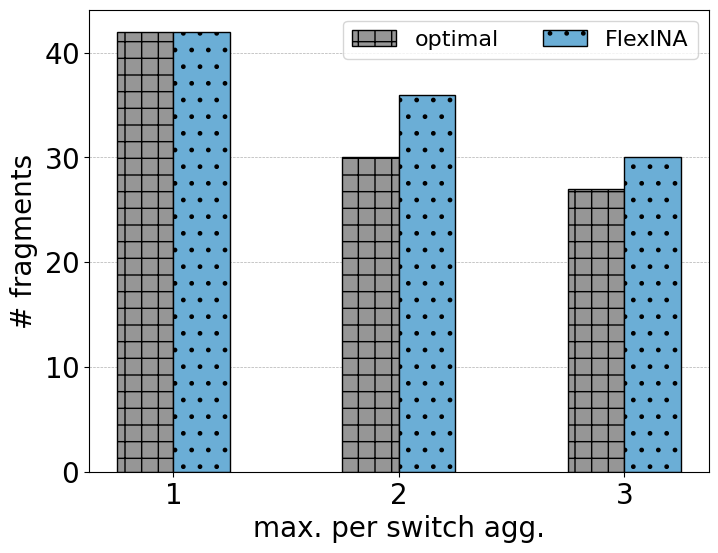

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['1', '2', '3']

C_1 = kindsofModelsPackets[defineModel]  # optimal
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.25  # عرض میله‌ها

hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width / 2, C_1, width, label='optimal', color=cmap[17], hatch=hatches[2])
rects2 = ax.bar(x + width / 2, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[1])

for rect in [rects1, rects2]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('max. per switch agg.')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1, 1), ncol=2,prop={'size': 16})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')
'''
#autolabel(rects1)
#autolabel(rects2)

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Number_of_Fragments_Aggregations_Optimal_FlexINA_itt3.pdf", bbox_inches="tight",format="pdf")
plt.show()


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['1', '2', '3']

C_1 = kindsofModelsPackets[defineModel]  # optimal
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA
error_C1 = [np.std(vals) for vals in errorPacketsM[defineModel]]

error_C5 = [np.std(vals) for vals in errorPacketsM[defineModel_selectedSwitches]]

x = np.arange(len(labels))
width = 0.25

hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width / 2, C_1, width, yerr=error_C1, capsize=5, label='optimal', color=cmap[17], hatch=hatches[2])
rects2 = ax.bar(x + width / 2, C_5, width, yerr=error_C5, capsize=5, label='FlexINA', color=cmap[1], hatch=hatches[1])

for rect in [rects1, rects2]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('max. per switch agg.')
ax.set_xticks(x)
ax.set_xticklabels(labels)

legend = ax.legend(loc= 1, bbox_to_anchor=(1, 1), ncol=2,prop={'size': 16})

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Number_of_Fragments_Aggregations_Optimal_FlexINA_ittr3_errorbar.pdf", bbox_inches="tight", format="pdf")
plt.show()


NameError: name 'kindsofModelsPackets' is not defined

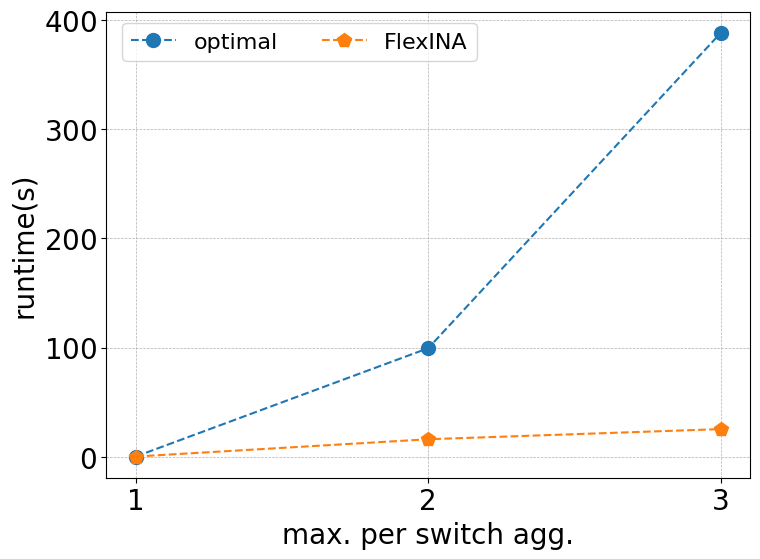

In [68]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['1','2','3']

fig, ax = plt.subplots(figsize=(8, 6))

y1 = kindsofModelsRuntime[defineModel]
#y2 = kindsofModelsRuntime[defineModel_ATP]
#y3 = kindsofModelsRuntime[defineModel_GRID]
#y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]

x1 = Kinds_of_Dependency
#x2 = Kinds_of_Dependency
#x3 = Kinds_of_Dependency
#x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency

plt.plot(x1, y1,ls = 'dashed',marker = 'o',markersize=10,label='optimal')
#plt.plot(x2, y2,ls = 'dashed',marker = 's',markersize=10,label='fixR-ToRS')
#plt.plot(x3, y3,ls = 'dashed',marker = '*',markersize=10,label='fixR-AS')
#plt.plot(x4, y4,ls = 'dashed',marker = '^',markersize=10,label='flexR-ToRS')
plt.plot(x5, y5,ls = 'dashed',marker = 'p',markersize=10,label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1), ncol=2 ,prop={'size': 16} )
plt.xlabel('max. per switch agg.')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "RunTime_Aggregations_Optimal_FlexINA_ittr3.pdf", bbox_inches="tight", format="pdf")
plt.show()


[np.float64(0.003587721882261243), np.float64(0.9028683669716143), np.float64(11.001375178541062)]


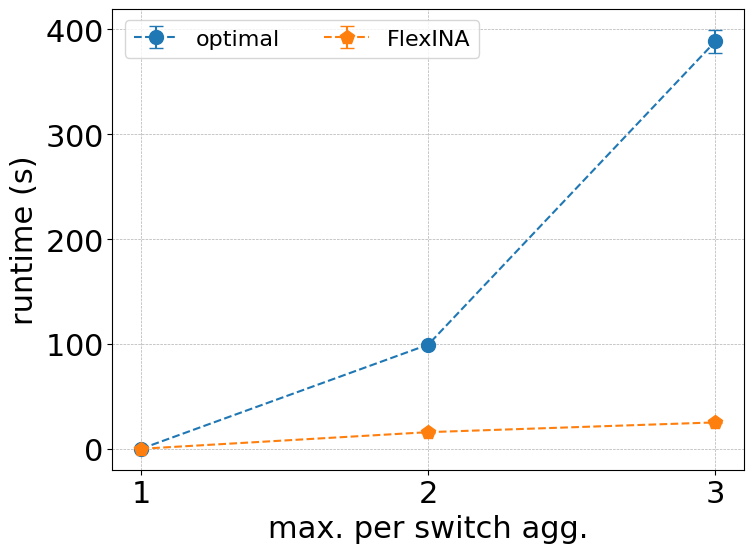

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# از همین کلیدها استفاده می‌کنیم چون توی داده‌ها همینطور اومده
model_key = list(errorRuntimesM.keys())[0]
flex_key = list(errorRuntimesM.keys())[1]

Kinds_of_Dependency = ['1', '2', '3']
x = Kinds_of_Dependency

# محاسبه میانگین زمان اجرا
y1 = kindsofModelsRuntime[defineModel]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]

# محاسبه خطای انحراف معیار
error_y1 = [np.std(vals) for vals in errorRuntimesM[model_key]]
print(error_y1)
error_y5 = [np.std(vals) for vals in errorRuntimesM[flex_key]]

# ترسیم نمودار با error bar
fig, ax = plt.subplots(figsize=(8, 6))

plt.errorbar(x, y1, yerr=error_y1, fmt='o--', markersize=10, capsize=5, label='optimal')
plt.errorbar(x, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1), ncol=2 ,prop={'size': 16})
plt.xlabel('max. per switch agg.')
plt.ylabel('runtime (s)')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))
ax.yaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.grid(linestyle='--', linewidth=0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig("RunTime_Aggregations_Optimal_FlexINA_with_errorbar_ittr3.pdf", bbox_inches="tight", format="pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['1', '2', '3']

C_1 = kindsofModelsRuntime[defineModel]  # فرضی: optimal
C_5 = kindsofModelsRuntime[defineModel_selectedSwitches]  # فرضی: FlexINA

error_C1 = [10, 12, 11]  # خطای optimal
error_C5 = [8, 10, 9]    # خطای FlexINA

x = np.arange(len(labels))
width = 0.25

hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - width / 2, C_1, width, yerr=error_C1, capsize=5, label='optimal', color=cmap[17], hatch=hatches[2])
rects2 = ax.bar(x + width / 2, C_5, width, yerr=error_C5, capsize=5, label='FlexINA', color=cmap[1], hatch=hatches[1])

for rect in [rects1, rects2]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('max. per switch agg.')
ax.set_xticks(x)
ax.set_xticklabels(labels)

legend = ax.legend(loc=1, bbox_to_anchor=(1, 1), ncol=1, prop={'size': 12})

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("RunTime_Aggregations_Optimal_FlexINA_ittr10_errorbar1.pdf", bbox_inches="tight", format="pdf")
plt.show()


In [64]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        #env_1Cluster,
        env_2Clusters
        #env_2Clusters_Zipf15,
        #env_2Clusters_Zipf2
        #env_3Clusters,
        #env_Test
        ]

models = [#defineModel,
          defineModel_ATP,
          defineModel_GRID,
          defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 4
ittrNum = 3
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
percentage = 0.6
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
errorRuntimesM = dict()
errorPacketsM = dict()
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
T_max_2_Array = [6, 7, 8, 9]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    #numPackets2 = []
    #RuntimeTotal2 = []
    #for envTemp in envs:
    #for percentage in Percentages:
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        #envTemp = env_2Clusters
    for envTemp in envs:
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        numPackets2 = []
        RuntimeTotal2 = []
        errorRuntime = []
        errorPackets = []
        for maxAggregation in range(1, maxAggregate):
            errorRuntime.append([])
            errorPackets.append([])
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = 8
                addTime = int(1 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
            numPackets2.append(sum(avgPacket)/len(avgPacket))   
            RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
        kindsofModelsPackets[modelSolve] = numPackets2
        kindsofModelsRuntime[modelSolve] = RuntimeTotal2
        errorRuntimesM[modelSolve] = errorRuntime
        errorPacketsM[modelSolve] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_ATP at 0x0000024DEBB7F6A0>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 756
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
0
Run Time 0.008654356002807617
optimal
Optimal objective value: 16.0
Y_Variables:
  Y{'A0'},0,2,1: 1.0
  Y{'A2'},1,2,2: 1.0
  Y{'A4'},4,3,3: 1.0
  Y{'A6'},5,3,4: 1.0
  Y{'A4'},7,3,4: 1.0
  Y{'A4'},9,2,5: 1.0
  Y{'A0'},2,2,2: 1.0
  Y{'A0'},8,2,3: 1.0
  Y{'A6'},7,3,5: 1.0
  Y{'A6'},9,2,6: 1.0
  Y{'A2'},2,2,3: 1.0
  Y{'A2'},8,2,4: 1.0
  Y{'A0'},11,0,0: 1.0
  Y{'A2'},33,0,1: 1.0
  Y{'A4'},55,0,2: 1.0
  Y{'A6'},77,0,3: 1.0
Z_Variables:
Number of Y_Variables: 756
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

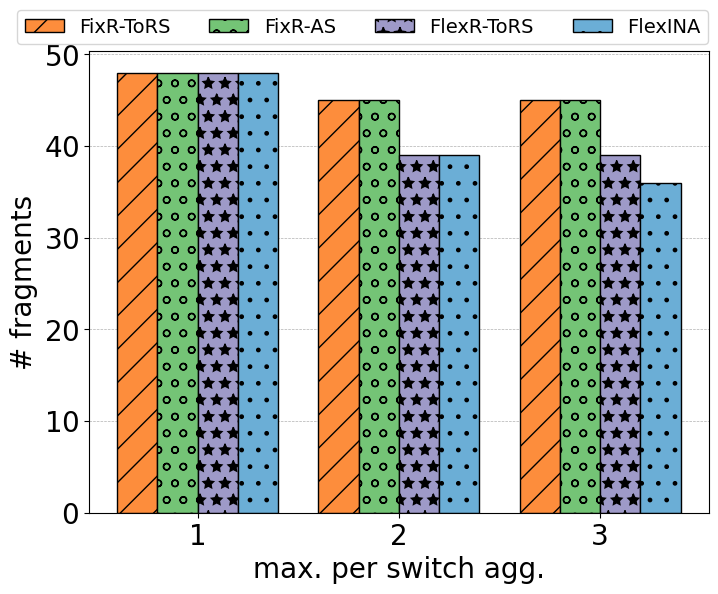

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['1', '2', '3']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('max. per switch agg.')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.11), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Number_of_Fragments_Aggregations_ittr3.pdf", bbox_inches="tight",format="pdf")
plt.show()


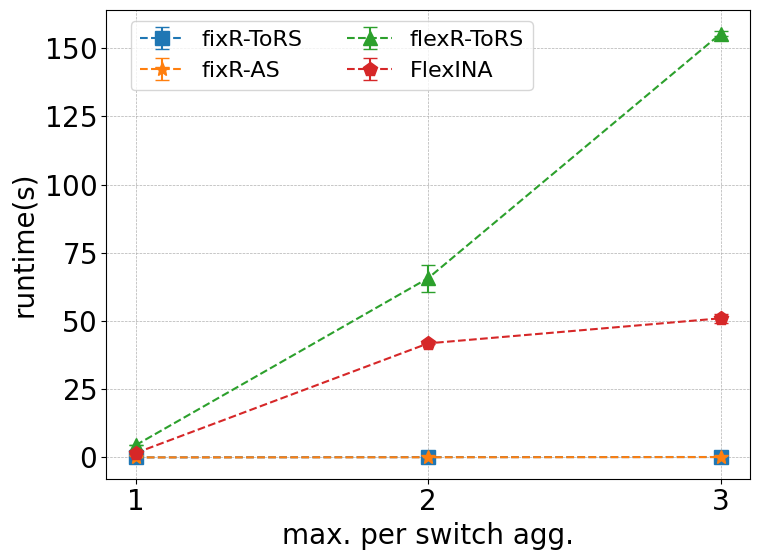

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['1','2','3']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]
error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]

x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency

#plt.plot(x1, y1,ls = 'dashed',marker = 'o',markersize=10,label='optimal')
plt.errorbar(x2, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
#plt.plot(x2, y2,yerr=error_y2,ls = 'dashed',marker = 's',markersize=10,label='fixR-ToRS')
#plt.plot(x3, y3,yerr=error_y3,ls = 'dashed',marker = '*',markersize=10,label='fixR-AS')
plt.errorbar(x3, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
#plt.plot(x4, y4,yerr=error_y4,ls = 'dashed',marker = '^',markersize=10,label='flexR-ToRS')
plt.errorbar(x4, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
#plt.plot(x5, y5,yerr=error_y5,ls = 'dashed',marker = 'p',markersize=10,label='FlexINA')
plt.errorbar(x5, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.35, 1), ncol=2 ,prop={'size': 16})
plt.xlabel('max. per switch agg.')
plt.ylabel('runtime(s)')

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "Runtime_Aggregations_ittr3_error.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [67]:
#model, Z_Variables , Y_Variables

#envs = [env_tree,
        #env_1Cluster,
        #env_2Clusters
        #env_3Clusters
        #]
envs = [env_tree,
        env_tree_Three,
        env_tree_Four
       
    #env_1Cluster_Test, 
        #env_1Cluster_Test_2,
        #env_1Cluster_Test_3
        #env_2Clusters_Percentages
        #env_1Cluster,
        #env_1Cluster2,
        #env_1Cluster3
        ]

models = [#defineModel,
          #defineModel_ATP,
          #defineModel_GRID,
          #defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
errorRuntimesM = dict()
errorPacketsM = dict()
maxAggregate = 3
ittrNum = 1
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
percentage = 0.2
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
T_max_2_Array = [6]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    numPackets2 = []
    RuntimeTotal2 = []
    #for envTemp in envs:
    #for percentage in Percentages:
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        #envTemp = env_2Clusters
    errorRuntime = []
    errorPackets = []
    for envTemp in envs:
        print('??????????????????????????????????????????????'+str(envTemp))
        errorRuntime.append([])
        errorPackets.append([])
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        #numPackets2 = []
        #RuntimeTotal2 = []
        for maxAggregation in range(2, maxAggregate):
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                if envTemp == env_tree:
                    T_max_2 = 7
                elif envTemp == env_tree_Three:
                    T_max_2 = 18
                elif envTemp == env_tree_Four:
                    T_max_2 = 20   
                addTime = int(1 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintMultiSlots(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
        numPackets2.append(sum(avgPacket)/len(avgPacket))   
        RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
    kindsofModelsPackets[modelSolve] = numPackets2
    kindsofModelsRuntime[modelSolve] = RuntimeTotal2
    errorRuntimesM[modelSolve] = errorRuntime
    errorPacketsM[modelSolve] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_selectedSwitches at 0x00000259FF49CEA0>
??????????????????????????????????????????????<function env_tree at 0x00000259FF411440>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 1593
Number of Z_Variables: 135
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Run Time 0.14990615844726562
optimal
Optimal objective value: 14.0
Y_Variables:
  Y{'A6'},3,1,2: 1.0
  Y{'A6'},5,4,3: 1.0
  Y{'A6'},6,2,4: 1.0
  Y{'A0'},0,0,3: 1.0
  Y{'A2'},1,0,4: 1.0
  Y{'A4'},2,1,3: 1.0
  Y{'A4'},5,4,4: 1.0
  Y{'A4'},6,2,5: 1.0
  Y{'A0', 'A2'},4,4,5: 1.0
  Y{'A0', 'A2'},6,2,6: 1.0
  Y{'A0'},11,0,2: 1.0
  Y{'A2'},33,0,3: 1.0
  Y{'A4'},55,0,2: 1.0
  Y{'A6'},77,0,1: 1.0
Z_Variables:
  Z[{'A0'}, {'A2'}],0,4,4,5: 1.0
Number of Y_Variables: 1593
Number of Z_Variables: 135
+++++++++++++++++++++++++

MemoryError: SCIP: insufficient memory error!

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

# Define color palette
cmap = sns.color_palette("tab20c")

# Data
x = np.array(["Tree", "Three_Tree", "Four_Tree"])
y = np.array([0.23863816261291504, 0.48981642723083496, 0.5911757946014404])
#y = np.array([14+14+14,11+12+12,11+12+12,11+12+12])
#y = np.array(kindsofModelsPackets[defineModel_selectedSwitches])

# List of colors for each bar
colors = [cmap[4]]
hatches = ['/', '/', '/', '/', '/', '/', '/', '/', '/', '/']
# Create figure and axis objects
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the bar chart
bars = ax.bar(x, y, color=colors, edgecolor='black')

# Add hatches to each bar
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Set labels
ax.set_ylabel('Runtime(s)')
ax.set_xlabel('Numbre of fragments')


ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x)

# Set grid, formatter, and other options on the axis
ax.grid(axis='y', linestyle='--', linewidth=0.5)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 25})
#ax.set_yscale('log')
# Save the figure
plt.savefig("Scalability_Tree.pdf", bbox_inches="tight", format="pdf")

# Display the plot
plt.show()


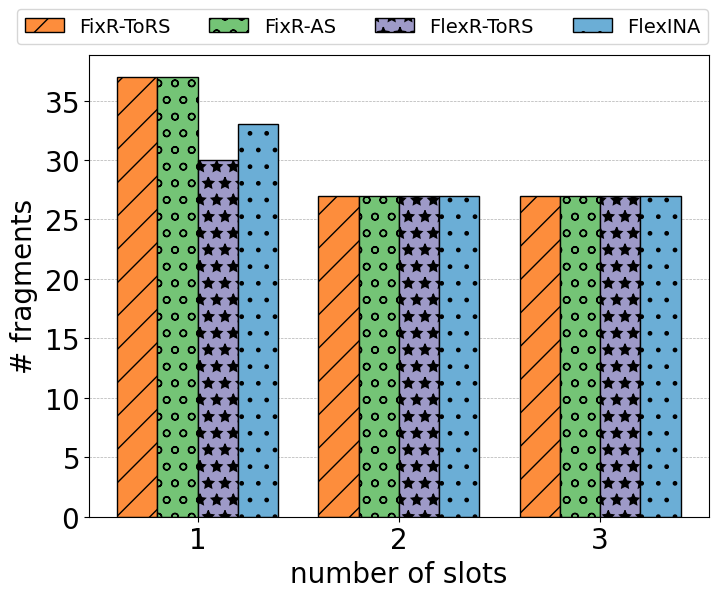

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['1','2','3']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('number of slots')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.12), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
#plt.savefig("Envs_Packets.pdf", bbox_inches="tight",format="pdf")
plt.savefig("Slot_Packets.pdf", bbox_inches="tight",format="pdf")
plt.show()


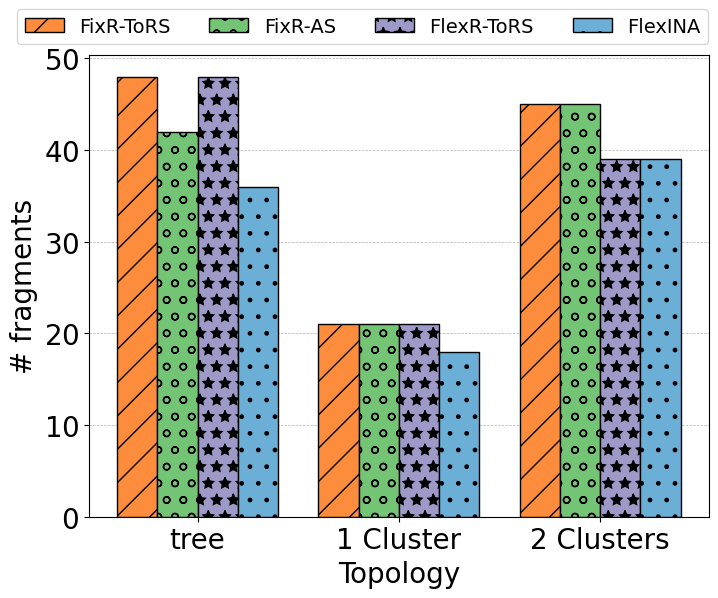

In [95]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['tree','1 Cluster' , '2 Clusters']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('Topology')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.12), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Envs_Packets.pdf", bbox_inches="tight",format="pdf")
plt.show()


In [103]:
'''
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns
cmap = sns.color_palette("tab20c")
labels = ['tree','1 Cluster' , '2 Clusters' , '3 Clusters']


C_1 = kindsofModelsPackets[defineModel]
C_2 = kindsofModelsPackets[defineModel_ATP]
C_3 = kindsofModelsPackets[defineModel_GRID]
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]
x = np.arange(len(labels))  # the label locations
width = 0.18  # the width of the bars
hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']
fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - 2 * width, C_1, width, label='optimal', color=cmap[1],hatch=hatches[1])
rects2 = ax.bar(x - width, C_2, width, label='fixR-ToRS', color=cmap[5],hatch=hatches[0])
rects3 = ax.bar(x, C_3, width, label='fixR-AS', color=cmap[9],hatch=hatches[5])
rects4 = ax.bar(x + width, C_4, width, label='flexR-ToRS', color=cmap[13],hatch=hatches[3])
rects5 = ax.bar(x + 2 * width, C_5, width, label='FlexINA', color=cmap[17], hatch=hatches[2])
for rect in [rects1, rects2, rects3, rects4,rects5]:
    for r in rect:
        r.set_edgecolor('black')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Fragments passing the network')
ax.set_xlabel('Topology')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()


def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(''),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)
fig.tight_layout()
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(0.95, 1.09), ncol=5,prop={'size': 10})

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
#plt.savefig("Envs_Packets.pdf", bbox_inches="tight",format="pdf")
plt.show()
'''

'\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport matplotlib.colors as mcolors\nimport matplotlib.ticker as ticker\nimport seaborn as sns\ncmap = sns.color_palette("tab20c")\nlabels = [\'tree\',\'1 Cluster\' , \'2 Clusters\' , \'3 Clusters\']\n\n\nC_1 = kindsofModelsPackets[defineModel]\nC_2 = kindsofModelsPackets[defineModel_ATP]\nC_3 = kindsofModelsPackets[defineModel_GRID]\nC_4 = kindsofModelsPackets[defineModel_ATP_GRID]\nC_5 = kindsofModelsPackets[defineModel_selectedSwitches]\nx = np.arange(len(labels))  # the label locations\nwidth = 0.18  # the width of the bars\nhatches = [\'/\', \'.\', \'+\', \'*\', \'\\\', \'o\', \'-\', \'x\', \'O\']\nfig, ax = plt.subplots(figsize=(8, 6))\nrects1 = ax.bar(x - 2 * width, C_1, width, label=\'optimal\', color=cmap[1],hatch=hatches[1])\nrects2 = ax.bar(x - width, C_2, width, label=\'fixR-ToRS\', color=cmap[5],hatch=hatches[0])\nrects3 = ax.bar(x, C_3, width, label=\'fixR-AS\', color=cmap[9],hatch=hatches[5])\nrec

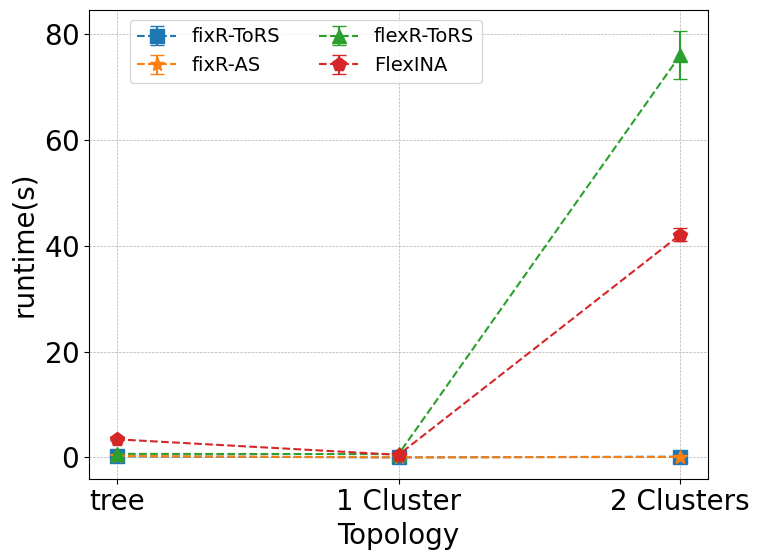

In [96]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['tree','1 Cluster','2 Clusters']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]

x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency

#plt.plot(x1, y1,ls = 'dashed',marker = 'o',markersize=10,label='optimal')
error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]
plt.errorbar(x2, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
plt.errorbar(x3, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
plt.errorbar(x4, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
plt.errorbar(x5, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.35, 1), ncol=2 ,prop={'size': 14} )
plt.xlabel('Topology')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "Envs_Runtime.pdf", bbox_inches="tight", format="pdf")
plt.show()

<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
C:\Users\mmdsb\AppData\Local\Temp\ipykernel_7492\1768692973.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('runtime (s, $\log_{10}$ scale)')


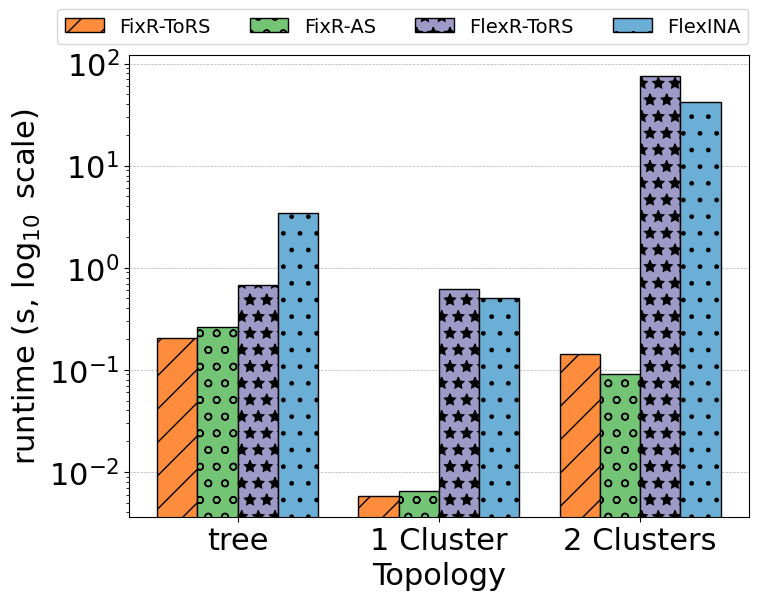

In [97]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['tree','1 Cluster' , '2 Clusters']

C_2 = kindsofModelsRuntime[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsRuntime[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsRuntime[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsRuntime[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

#ax.set_ylabel('runtime(s)')
ax.set_ylabel('runtime (s, $\log_{10}$ scale)')

ax.set_xlabel('Topology')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.12), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
ax.set_yscale('log')
plt.savefig("Envs_Runtime_New.pdf", bbox_inches="tight",format="pdf")
plt.show()


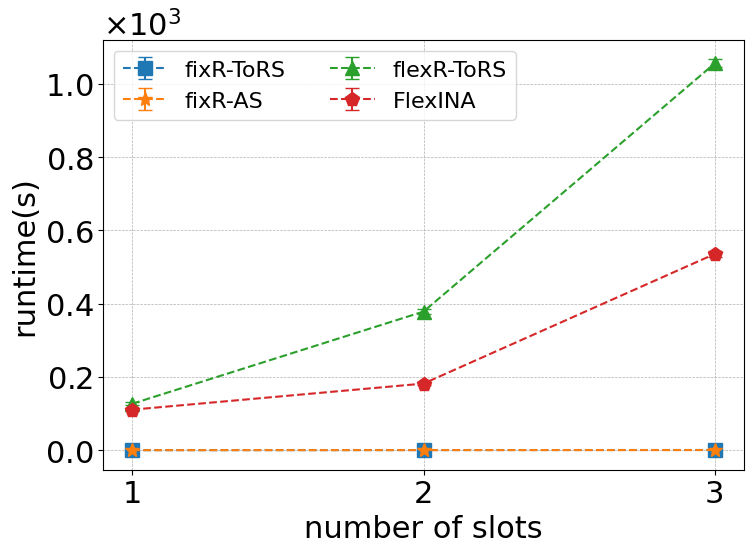

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
#Kinds_of_Dependency = ['1','2','3']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]

error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]

x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency
plt.errorbar(x2, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
plt.errorbar(x3, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
plt.errorbar(x4, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
plt.errorbar(x5, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.33, 1), ncol=2 ,prop={'size': 16} )
plt.xlabel('number of slots')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
#plt.savefig( "Envs_Runtime.pdf", bbox_inches="tight", format="pdf")
plt.savefig( "Slots_Runtime.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [ ]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        #env_1Cluster,
        env_2Clusters_Percentages
        #env_1Cluster2    
        #env_3Clusters
        ]

models = [#defineModel,
          #defineModel_ATP,
          #defineModel_GRID,
          #defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 3
ittrNum = 1
#Percentages = [0.1, 0.3,0.5,0.7]#, 0.4, 0.8, 1]
Percentages = [0.4]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
#percentage = 0.6
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
errorRuntimesM = dict()
errorPacketsM = dict()
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
#T_max_2_Array = [6, 7, 8, 9]
T_max_2_Array = [7]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    numPackets2 = []
    RuntimeTotal2 = []
    #for envTemp in envs:
    errorRuntime = []
    errorPackets = []
    for percentage in Percentages:
        errorRuntime.append([])
        errorPackets.append([])
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        envTemp = env_2Clusters_Percentages
    #for envTemp in envs:
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        #numPackets2 = []
        #RuntimeTotal2 = []
        for maxAggregation in range(2, maxAggregate):
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = 6
                addTime = int(1 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    print(">>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(numPacket))
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)    
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)   
            numPackets2.append(numPackets)   
            RuntimeTotal2.append(RuntimeTotal)
        numPackets2.append(sum(avgPacket)/len(avgPacket))   
        RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
    kindsofModelsPackets[modelSolve] = numPackets2
    kindsofModelsRuntime[modelSolve] = RuntimeTotal2
    errorRuntimesM[percentage] = errorRuntime
    errorPacketsM[percentage] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_selectedSwitches at 0x000001E16AC8DBC0>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 1196
Number of Z_Variables: 20
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Run Time 0.30980539321899414
optimal
Optimal objective value: 12.0
Y_Variables:
  Y{'A0'},0,3,2: 1.0
  Y{'A2'},1,3,1: 1.0
  Y{'A0', 'A2'},3,3,3: 1.0
  Y{'A6'},5,2,2: 0.9999999999999999
  Y{'A4'},4,2,1: 1.0
  Y{'A6', 'A4'},6,2,3: 0.9999999999999999
  Y{'A6', 'A4'},8,2,4: 0.9999999999999999
  Y{'A0', 'A2'},9,2,4: 1.0
  Y{'A0'},11,0,1: 1.0
  Y{'A2'},33,0,0: 1.0
  Y{'A4'},55,0,0: 1.0
  Y{'A6'},77,0,1: 0.9999999999999999
Z_Variables:
  Z[{'A0'}, {'A2'}],0,3,2,3: 1.0
  Z[{'A6'}, {'A4'}],0,6,2,3: 0.9999999999999999
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>12.0
Number of Y_Variables: 1196
Number of Z_Varia

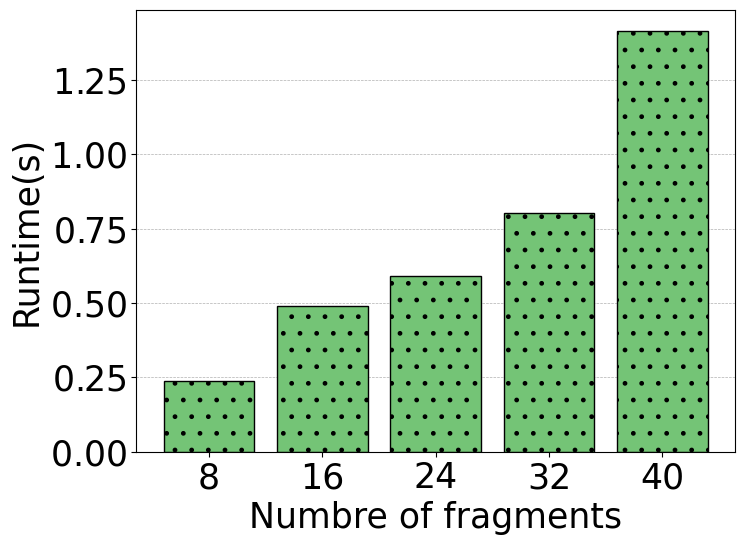

In [89]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

# Define color palette
cmap = sns.color_palette("tab20c")

# Data
x = np.array(["8", "16", "24", "32", "40"])
y = np.array([0.23863816261291504, 0.48981642723083496, 0.5911757946014404, 0.8037800788879395, 1.414642095565796])
#y = np.array([14+14+14,11+12+12,11+12+12,11+12+12])
#y = np.array(kindsofModelsPackets[defineModel_selectedSwitches])

# List of colors for each bar
colors = [cmap[9]]
hatches = ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.']
# Create figure and axis objects
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the bar chart
bars = ax.bar(x, y, color=colors, edgecolor='black')

# Add hatches to each bar
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Set labels
ax.set_ylabel('Runtime(s)')
ax.set_xlabel('Numbre of fragments')


ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x)

# Set grid, formatter, and other options on the axis
ax.grid(axis='y', linestyle='--', linewidth=0.5)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 25})
#ax.set_yscale('log')
# Save the figure
plt.savefig("Scalability_FragmentsNumm.pdf", bbox_inches="tight", format="pdf")

# Display the plot
plt.show()


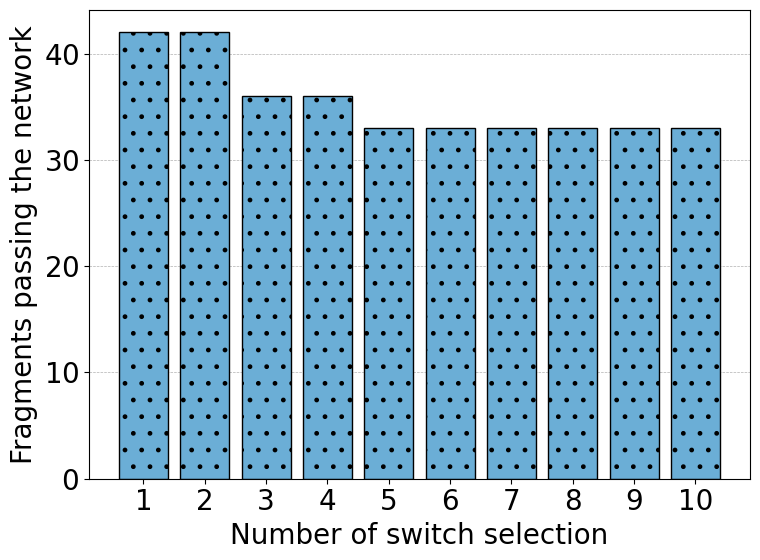

In [59]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

# Define color palette
cmap = sns.color_palette("tab20c")

# Data
x = np.array(["1", "3","5", "7"])
#y = np.array([14+14+14,11+12+12,11+12+12,11+12+12])
y = np.array(kindsofModelsPackets[defineModel_selectedSwitches])

# List of colors for each bar
colors = [cmap[1]]
hatches = ['.', '.', '.', '.', '.', '.', '.', '.', '.', '.']
# Create figure and axis objects
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the bar chart
bars = ax.bar(x, y, color=colors, edgecolor='black')

# Add hatches to each bar
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Set labels
ax.set_ylabel('# fragments')
ax.set_xlabel('numbre of switch selection')

ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x)

# Set grid, formatter, and other options on the axis
ax.grid(axis='y', linestyle='--', linewidth=0.5)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})

# Save the figure
plt.savefig("Percentage_Number_of_Packet_ittr3.pdf", bbox_inches="tight", format="pdf")

# Display the plot
plt.show()


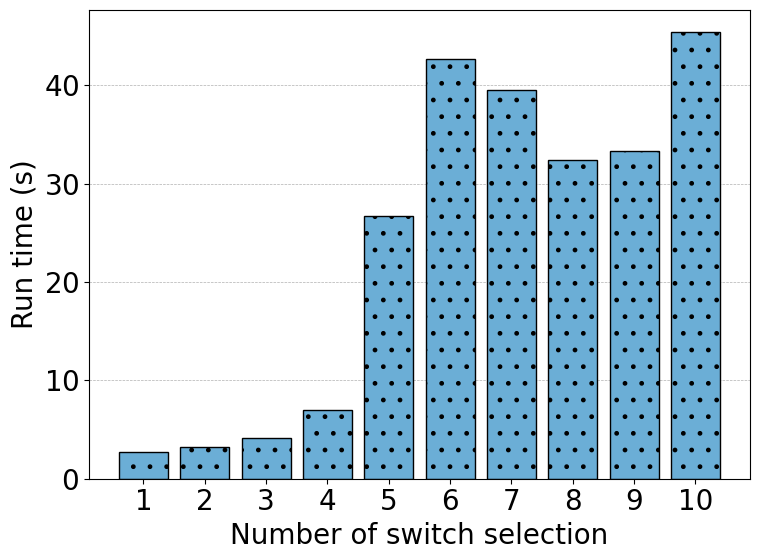

In [60]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

# Define color palette
cmap = sns.color_palette("tab20c")

# Data
x = np.array(["1", "3","5", "7"])
#y = np.array([0.9512295722961426+2.762094259262085+1.1550698280334473,28.6581871509552+6.898907423019409+12.30421257019043,44.657066345214844+31.76844310760498+36.61665487289429,36.299466133117676+35.08411192893982+52.84385895729065])
y = np.array(kindsofModelsRuntime[defineModel_selectedSwitches])

# List of colors for each bar
colors = [cmap[1]]
hatches = ['.', '.', '.', '.','.', '.', '.', '.','.', '.']
# Create figure and axis objects
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the bar chart
bars = ax.bar(x, y, color=colors, edgecolor='black')

# Add hatches to each bar
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

# Set labels
ax.set_ylabel('runtime (s)')
ax.set_xlabel('number of switch selection')
ax.set_xticks(np.arange(len(x)))
ax.set_xticklabels(x)

# Set grid, formatter, and other options on the axis
ax.grid(axis='y', linestyle='--', linewidth=0.5)
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})

# Save the figure
plt.savefig("Percentage_Runtime_ittr3_error.pdf", bbox_inches="tight", format="pdf")

# Display the plot
plt.show()


In [ ]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        env_1Cluster
        #env_2Clusters
        #env_3Clusters
        ]

models = [#defineModel,
          defineModel_ATP,
          defineModel_GRID,
          defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

    
errorRuntimesM = dict()
errorPacketsM = dict()        
#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 3
ittrNum = 3
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
percentage = 0.6
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
#T_max_2_Array = [8, 9, 10, 11]
T_max_2_Array = [8, 9, 10, 11]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    numPackets2 = []
    RuntimeTotal2 = []
    #for envTemp in envs:
    #for percentage in Percentages:
    errorRuntime = []
    errorPackets = []
    for T_max_2_index in T_max_2_Array:
        errorRuntime.append([])
        errorPackets.append([])
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        envTemp = env_2Clusters
    #for envTemp in envs:
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        #numPackets2 = []
        #RuntimeTotal2 = []
        for maxAggregation in range(2, maxAggregate):
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = T_max_2_index
                addTime = int(0.6 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)  
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
        numPackets2.append(sum(avgPacket)/len(avgPacket))   
        RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
    kindsofModelsPackets[modelSolve] = numPackets2
    kindsofModelsRuntime[modelSolve] = RuntimeTotal2
    errorRuntimesM[modelSolve] = errorRuntime
    errorPacketsM[modelSolve] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_ATP at 0x000002567686B600>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 756
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 214
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
0
Run Time 0.04280376434326172
optimal
Optimal objective value: 15.0
Y_Variables:
  Y{'A0'},0,2,1: 1.0
  Y{'A2'},1,2,2: 1.0
  Y{'A4'},4,3,3: 1.0
  Y{'A6'},5,3,4: 1.0
  Y{'A4'},7,3,4: 1.0
  Y{'A4'},9,2,5: 1.0
  Y{'A0'},2,2,2: 1.0
  Y{'A6'},7,3,5: 1.0
  Y{'A6'},9,2,6: 1.0
  Y{'A2'},2,2,3: 1.0
  Y{'A0', 'A2'},8,2,4: 1.0
  Y{'A0'},11,0,0: 1.0
  Y{'A2'},33,0,1: 1.0
  Y{'A4'},55,0,2: 1.0
  Y{'A6'},77,0,3: 1.0
Z_Variables:
  Z[{'A0'}, {'A2'}],0,8,3,4: 1.0
Number of Y_Variables: 693
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 208
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

In [2]:
A1 = [45.0, 45.0, 45.0, 45.0]
A2 = [45.0, 45.0, 45.0, 45.0]
A3 = [39.0, 38.99999999999998, 39.0, 38.99999999999997]
A4 = [39.0, 38.99999999999998, 39.0, 38.99999999999997]
B1 = [0.12452483177185059, 0.14149117469787598, 0.1751539707183838, 0.21650433540344238]
B2 = [0.07270979881286621, 0.09792017936706543, 0.12230396270751953, 0.15563535690307617]
B3 = [38.15016770362854, 147.9564266204834, 422.09288573265076, 1190.777949810028]
B4 = [25.456961631774902, 94.8836464881897, 191.58964943885803, 383.09469294548035]

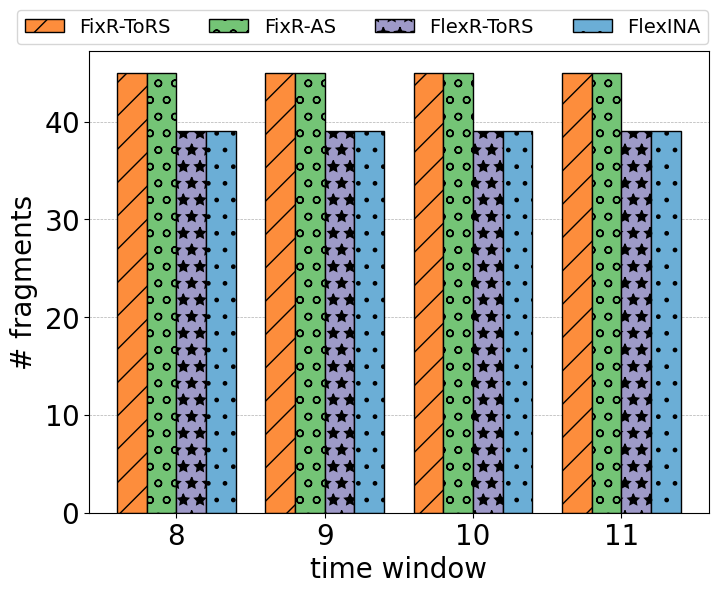

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['8', '9', '10', '11']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel( 'time window')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.11), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Start_Time_Number_of_Fragments_2Clusters.pdf", bbox_inches="tight", format="pdf")
plt.show()


In [60]:
'''
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns

cmap = sns.color_palette("tab20c")
labels = ['8', '9', '10', '11']


C_1 = kindsofModelsPackets[defineModel]
C_2 = kindsofModelsPackets[defineModel_ATP]
C_3 = kindsofModelsPackets[defineModel_GRID]
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]

x = np.arange(len(labels))  # the label locations
width = 0.18  # the width of the bars

hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']

fig, ax = plt.subplots(figsize=(8, 6))

# Adjusted bar positions for 3 bars per group
rects1 = ax.bar(x - 2 * width, C_1, width, label='optimal', color=cmap[1],hatch=hatches[1])
rects2 = ax.bar(x - width, C_2, width, label='fixR-ToRS', color=cmap[5],hatch=hatches[0])
rects3 = ax.bar(x, C_3, width, label='fixR-AS', color=cmap[9],hatch=hatches[5])
rects4 = ax.bar(x + width, C_4, width, label='flexR-ToRS', color=cmap[13],hatch=hatches[3])
rects5 = ax.bar(x + 2 * width, C_5, width, label='FlexINA', color=cmap[17], hatch=hatches[2])

# Adding edge color to bars
for rect in [rects1, rects2, rects3, rects4, rects5]:
    for r in rect:
        r.set_edgecolor('black')

# Labels and title
ax.set_ylabel('Fragments passing the network')
ax.set_xlabel('Start Time')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Function to add value labels above bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(''),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Final adjustments
fig.tight_layout()
#ax.legend(loc= 1, bbox_to_anchor=(0.7, 1), ncol= 1, prop={'size': 11})

legend = ax.legend(loc= 1, bbox_to_anchor=(0.95, 1.09), ncol=5,prop={'size': 10})
# Setting scientific notation for y-axis
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

# Grid and display
plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
#plt.savefig("Start_Time_Number_of_Fragments_2Clusters.pdf", bbox_inches="tight", format="pdf")
plt.show()
'''

'\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport matplotlib.colors as mcolors\nimport matplotlib.ticker as ticker\nimport seaborn as sns\n\ncmap = sns.color_palette("tab20c")\nlabels = [\'8\', \'9\', \'10\', \'11\']\n\n\nC_1 = kindsofModelsPackets[defineModel]\nC_2 = kindsofModelsPackets[defineModel_ATP]\nC_3 = kindsofModelsPackets[defineModel_GRID]\nC_4 = kindsofModelsPackets[defineModel_ATP_GRID]\nC_5 = kindsofModelsPackets[defineModel_selectedSwitches]\n\nx = np.arange(len(labels))  # the label locations\nwidth = 0.18  # the width of the bars\n\nhatches = [\'/\', \'.\', \'+\', \'*\', \'\\\', \'o\', \'-\', \'x\', \'O\']\n\nfig, ax = plt.subplots(figsize=(8, 6))\n\n# Adjusted bar positions for 3 bars per group\nrects1 = ax.bar(x - 2 * width, C_1, width, label=\'optimal\', color=cmap[1],hatch=hatches[1])\nrects2 = ax.bar(x - width, C_2, width, label=\'fixR-ToRS\', color=cmap[5],hatch=hatches[0])\nrects3 = ax.bar(x, C_3, width, label=\'fixR-AS\', color=c

NameError: name 'errorRuntimesM' is not defined

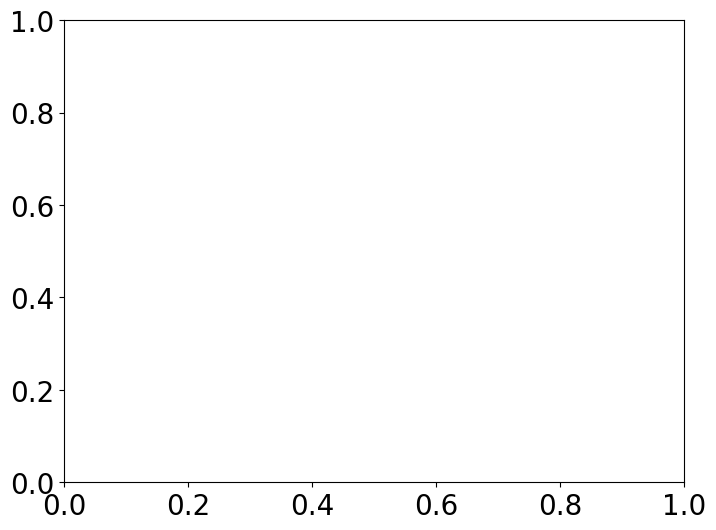

In [5]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['8' , '9' , '10' , '11']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]
error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]


# ترسیم نمودار با error bar
fig, ax = plt.subplots(figsize=(8, 6))
x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency
plt.errorbar(x2, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
plt.errorbar(x3, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
plt.errorbar(x4, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
plt.errorbar(x5, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')



#plt.plot(x2, y2,ls = 'dashed',marker = 's',markersize=10,label='fixR-ToRS')
#plt.plot(x3, y3,ls = 'dashed',marker = '*',markersize=10,label='fixR-AS')
#plt.plot(x4, y4,ls = 'dashed',marker = '^',markersize=10,label='flexR-ToRS')
#plt.plot(x5, y5,ls = 'dashed',marker = 'p',markersize=10,label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.33, 1), ncol=2 ,prop={'size': 16} )
plt.xlabel('time window')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "Start_Time_Runtime_2Clusters.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [69]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        #env_1Cluster,
        env_2Clusters
        #env_3Clusters
        ]

models = [#defineModel,
          defineModel_ATP,
          defineModel_GRID,
          defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 3
ittrNum = 3
errorRuntimesM = dict()
errorPacketsM = dict() 
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7,0.8]
PercentagesTimes = [0.4, 0.6, 1]
percentage = 0.6
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
T_max_2_Array = [8, 9, 10, 11]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    numPackets2 = []
    RuntimeTotal2 = []
    errorRuntime = []
    errorPackets = []
    #for envTemp in envs:
    for percentageTime in PercentagesTimes:
        errorRuntime.append([])
        errorPackets.append([])
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        envTemp = env_1Cluster_Test
    #for envTemp in envs:
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        #numPackets2 = []
        #RuntimeTotal2 = []
        for maxAggregation in range(2, maxAggregate):
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = 9
                addTime = int(percentageTime * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal)
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
        numPackets2.append(sum(avgPacket)/len(avgPacket))   
        RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
    kindsofModelsPackets[modelSolve] = numPackets2
    kindsofModelsRuntime[modelSolve] = RuntimeTotal2
    errorRuntimesM[modelSolve] = errorRuntime
    errorPacketsM[modelSolve] = errorPackets
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_ATP at 0x000001D34293D260>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 657
[0, 1, 2, 3]
Number of Z_Variables: 823
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
0
Run Time 0.06805181503295898
optimal
Optimal objective value: 13.0
Y_Variables:
  Y{'A0'},0,3,1: 1.0
  Y{'A0'},2,4,2: 1.0
  Y{'A2'},1,2,2: 1.0
  Y{'A2'},3,4,3: 1.0
  Y{'A6'},3,4,4: 1.0
  Y{'A4'},2,4,3: 1.0
  Y{'A0'},4,4,3: 1.0
  Y{'A4'},4,4,4: 1.0
  Y{'A2', 'A6'},4,4,5: 1.0
  Y{'A0'},11,0,0: 1.0
  Y{'A2'},33,0,1: 1.0
  Y{'A4'},55,0,2: 1.0
  Y{'A6'},77,0,3: 1.0
Z_Variables:
  Z[{'A2'}, {'A6'}],0,4,3,5: 1.0
Number of Y_Variables: 580
[0, 1, 2, 3]
Number of Z_Variables: 787
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

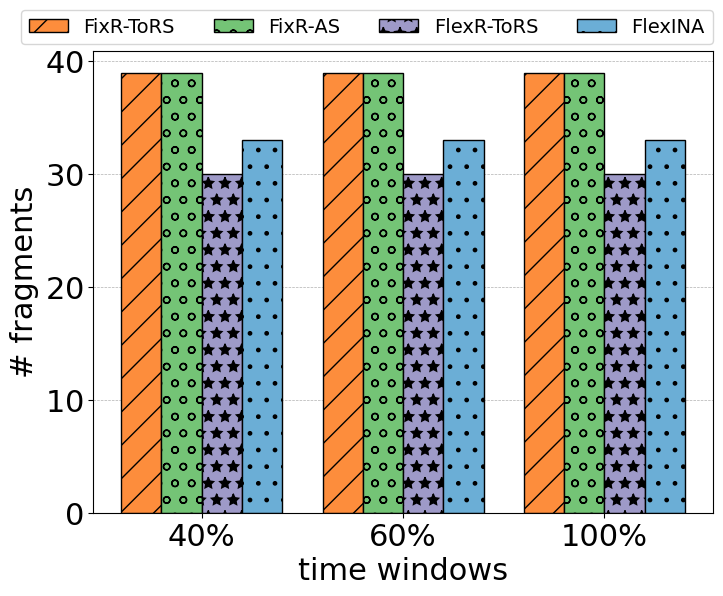

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['40%', '60%' , '100%']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('time windows')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.11), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Time_Window_Number_of_Fragments.pdf", bbox_inches="tight",format="pdf")
plt.show()


In [64]:
'''
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns
cmap = sns.color_palette("tab20c")
labels = ['50%', '60%', '70%', '80%']

C_1 = kindsofModelsPackets[defineModel]
C_2 = kindsofModelsPackets[defineModel_ATP]
C_3 = kindsofModelsPackets[defineModel_GRID]
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]

x = np.arange(len(labels))  # the label locations
width = 0.18  # the width of the bars, adjusted for five bars
hatches = ['/', '.', '+', '*', '\\', 'o', '-', 'x', 'O']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 2 * width, C_1, width, label='optimal', color=cmap[1],hatch=hatches[1])
rects2 = ax.bar(x - width, C_2, width, label='fixR-ToRS', color=cmap[5],hatch=hatches[0])
rects3 = ax.bar(x, C_3, width, label='fixR-AS', color=cmap[9],hatch=hatches[5])
rects4 = ax.bar(x + width, C_4, width, label='flexR-ToRS', color=cmap[13],hatch=hatches[3])
rects5 = ax.bar(x + 2 * width, C_5, width, label='FlexINA', color=cmap[17], hatch=hatches[2])

for rect in [rects1, rects2, rects3, rects4, rects5]:
    for r in rect:
        r.set_edgecolor('black')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Fragments passing the network')
ax.set_xlabel('Time windows')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(''),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Apply autolabel to all rects
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)  # Add autolabel for rects5

fig.tight_layout()
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(0.95, 1.09), ncol=5,prop={'size': 10})

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
#plt.savefig("Number_of_Fragments_Time_Window.pdf", bbox_inches="tight",format="pdf")
plt.show()
'''

'\nimport matplotlib\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport matplotlib.colors as mcolors\nimport matplotlib.ticker as ticker\nimport seaborn as sns\ncmap = sns.color_palette("tab20c")\nlabels = [\'50%\', \'60%\', \'70%\', \'80%\']\n\nC_1 = kindsofModelsPackets[defineModel]\nC_2 = kindsofModelsPackets[defineModel_ATP]\nC_3 = kindsofModelsPackets[defineModel_GRID]\nC_4 = kindsofModelsPackets[defineModel_ATP_GRID]\nC_5 = kindsofModelsPackets[defineModel_selectedSwitches]\n\nx = np.arange(len(labels))  # the label locations\nwidth = 0.18  # the width of the bars, adjusted for five bars\nhatches = [\'/\', \'.\', \'+\', \'*\', \'\\\', \'o\', \'-\', \'x\', \'O\']\n\nfig, ax = plt.subplots(figsize=(8, 6))\n\nrects1 = ax.bar(x - 2 * width, C_1, width, label=\'optimal\', color=cmap[1],hatch=hatches[1])\nrects2 = ax.bar(x - width, C_2, width, label=\'fixR-ToRS\', color=cmap[5],hatch=hatches[0])\nrects3 = ax.bar(x, C_3, width, label=\'fixR-AS\', color=cmap[9],hatch=hatches[5]

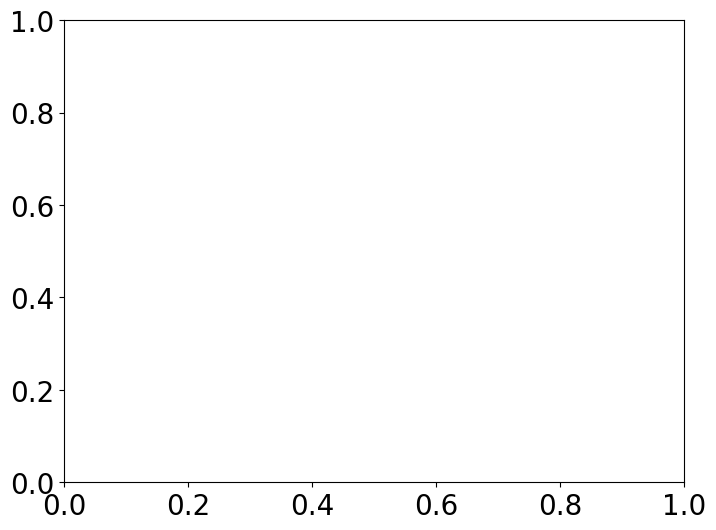

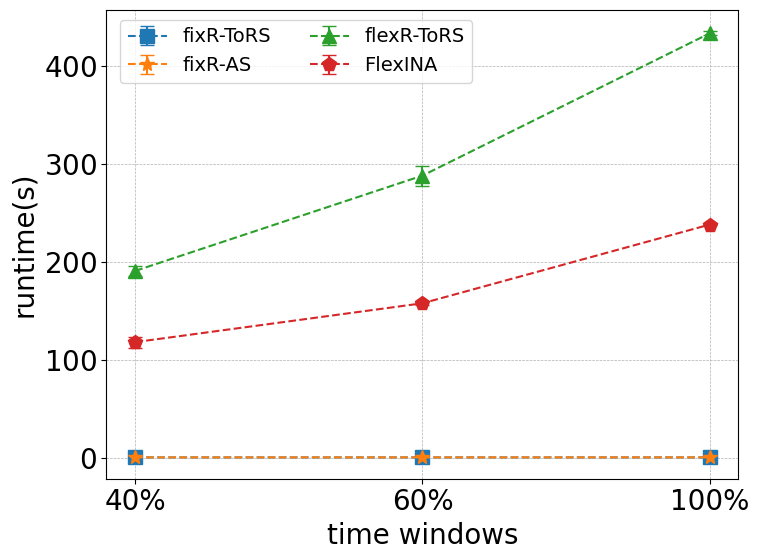

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['40%', '60%' , '100%']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]


error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]

# ترسیم نمودار با error bar
fig, ax = plt.subplots(figsize=(8, 6))
x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency
plt.errorbar(x2, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
plt.errorbar(x3, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
plt.errorbar(x4, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
plt.errorbar(x5, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')


plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1), ncol=2 ,prop={'size': 14} )
plt.xlabel('time windows')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "Time_Window_Runtime.pdf", bbox_inches="tight", format="pdf")
plt.show()

In [98]:
#model, Z_Variables , Y_Variables

envs = [#env_tree,
        #env_1Cluster,
        env_2Clusters,
        env_2Clusters_Zipf15,
        env_2Clusters_Zipf2
        #env_3Clusters
        ]

models = [#defineModel,
          defineModel_ATP,
          defineModel_GRID,
          defineModel_ATP_GRID,
          defineModel_selectedSwitches
         ]

#AllFinalWorkers = []
#finalWorkers = dict()
#workerKey = "None"
#for workerskey in fragmentsofEachWorker:
    #finalWorkers[workerskey] = totalWorkers[workerskey]

#num_dicts = len(next(iter(finalWorkers.values())))

#dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
#print(dict_list)
maxAggregate = 3
ittrNum = 3
#Percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
#PercentagesTimes = [0.5, 0.6, 0.7, 0.8]
percentage = 0.6
#T_max = [0, 6, 7, 9, 11]
avgPacket = []
avgRunTime = []
avgParamNumY = []
avgParamNumZ = []
errorRuntimesM = dict()
errorPacketsM = dict()

        
            
kindsofModelsPackets = dict()
kindsofModelsRuntime = dict()
T_max_2_Array = [6, 7, 8, 9]
for modelSolve in models:
    print("Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>"+str(modelSolve))
    #To Clusters envTemp
    numPackets2 = []
    RuntimeTotal2 = []
    errorRuntime = []
    errorPackets = []
    #for envTemp in envs:
    #for percentage in Percentages:
    #for T_max_2_index in T_max_2_Array:
        #print('??????????????????????????????????????????????'+str(T_max_2_index))
        #envTemp = env_2Clusters
    for envTemp in envs:
        errorRuntime.append([])
        errorPackets.append([])
        #print(envTemp)
        #if modelSolve == defineModel:
        pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        #else: 
            #pSwitchesTopology, pSwitchPorts, neighborsofEachSwitch, pSwitchesNumber, numberSlotsSwitches, workersTopology, pWorkerPorts,  workersNumber, numAllFrags, fragmentsofEachWorker, totalWorkers, stepsToSwitches, cutPorts, selectedSwitches, clusters = envTemp(state = 'Optimaze')
        
        AllFinalWorkers = []
        finalWorkers = dict()
        workerKey = "None"
        for workerskey in fragmentsofEachWorker:
            finalWorkers[workerskey] = totalWorkers[workerskey]
    
        num_dicts = len(next(iter(finalWorkers.values())))
    
        dict_list = [{k: [v[i]] for k, v in finalWorkers.items()} for i in range(num_dicts)]
        #numPackets2 = []
        #RuntimeTotal2 = []
        for maxAggregation in range(2, maxAggregate):
            #T_max_2 = T_max_2_index
            #T_max_2 = T_max[maxAggregation]
            for ittr in range(ittrNum):
                T_max_1 = 0
                T_max_2 = 8
                addTime = int(1 * (T_max_2))
                Y_Used = []
                Z_Used = []
                numPackets= 0
                RuntimeTotal = 0
                avgPacket = []
                avgRuntime = []
                for items in range(0, len(dict_list)):
                    #print(items)
                    fragmentsofEachWorker = dict_list[items]
                    #print(fragmentsofEachWorker)
                    subSets, allofSubsets, usefulIntervalTime, fragments = create_Fragments(fragmentsofEachWorker, T_max_1, T_max_2, maxAggregation)
                    Y_Used = preProcessMappingY(Y_Used, allofSubsets[0])
                    Z_Used = preProcessMappingZ(Z_Used, subSets, usefulIntervalTime)
                    #model, Z_Variables , Y_Variables, Prm1, Prm2 = defineModel(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,
                                #subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches)
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                    model, Z_Variables , Y_Variables, Prm1, Prm2, clusterSets, switchinClusters, AllClusters  = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches, percentage, clusters)
                        #print(clusterSets)
                        #print(clusterSets, switchinClusters, AllClusters)
                    #else:
                        #model, Z_Variables , Y_Variables, Prm1, Prm2 = modelSolve(allofSubsets, pSwitchesTopology, pSwitchPorts, T_max_1, T_max_2, workersTopology, fragmentsofEachWorker, pWorkerPorts,subSets, numberSlotsSwitches, usefulIntervalTime,Y_Used, Z_Used, maxAggregation, stepsToSwitches, cutPorts, selectedSwitches)
                    print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
                    #if modelSolve == defineModel_selectedSwitches or modelSolve == defineModel or modelSolve ==defineModel_ATP or modelSolve == defineModel_GRID:
                    constraintNum1selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum2selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used, clusterSets, switchinClusters, AllClusters)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitchesATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    else:
                        constraintNum3selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                        constraintNum4selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used, clusterSets, switchinClusters, AllClusters)
                    constraintNum7selectedSwitches(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used, clusterSets, switchinClusters, AllClusters)
                    #else:
                        #constraintNum1(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, Z_Used)
                        #constraintNum2(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, Z_Used)
                        #constraintNum3(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum4(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        #constraintNum7(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, pSwitchPorts, Z_Used, Y_Used)
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        constraintNum5ATP(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)  
                        #constraintNum6ATP(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    else:
                        constraintNum5(workersTopology, fragmentsofEachWorker, pWorkerPorts, model, T_max_1, T_max_2, Y_Used)
                        constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum6
                    #constraintNum6(pSwitchesTopology, numberSlotsSwitches, usefulIntervalTime, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Z_Used)
                    #constraintNum8
                    #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum9
                    #if modelSolve == defineModel_ATP and maxAggregation == 1:
                    if modelSolve == defineModel_ATP or modelSolve == defineModel_GRID:
                        pass
                    else:
                        #print("Hello")
                        constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #else:
                        #constraintNum9(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                        #constraintNum8(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, Y_Used)
                    #constraintNum10
                    constraintNum10(pSwitchesTopology, subSets, model, T_max_1, T_max_2, neighborsofEachSwitch, pSwitchPorts, numAllFrags, Y_Used)
                    #constraintNum11
                    constraintNum11(pSwitchesTopology, subSets, model, workersTopology, pSwitchPorts, Y_Used, T_max_1)  
                    #objective
                    objective(Y_Variables, model)
                    #Solve the problem
                    Y_Value_One, Z_Value_One, Y_Used, Z_Used, numPacket, Runtime, status = solveProblem(model, Y_Used, Z_Used)
                    T_max_1 += addTime
                    T_max_2 += addTime
                    numPackets += numPacket
                    RuntimeTotal += Runtime
                avgPacket.append(numPackets)
                avgRuntime.append(RuntimeTotal) 
                errorRuntime[len(errorRuntime)-1].append(RuntimeTotal)
                errorPackets[len(errorPackets)-1].append(numPackets)
            #numPackets2.append(numPackets)   
            #RuntimeTotal2.append(RuntimeTotal)
        numPackets2.append(sum(avgPacket)/len(avgPacket))   
        RuntimeTotal2.append(sum(avgRuntime)/len(avgRuntime))
    errorRuntimesM[modelSolve] = errorRuntime
    errorPacketsM[modelSolve] = errorPackets    
    kindsofModelsPackets[modelSolve] = numPackets2
    kindsofModelsRuntime[modelSolve] = RuntimeTotal2
print(kindsofModelsPackets)
print(kindsofModelsRuntime)

Model>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>><function defineModel_ATP at 0x000001688206F060>
{11: ['A0'], 33: ['A2'], 55: ['A4'], 77: ['A6']}
Number of Y_Variables: 756
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 214
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
0
Run Time 0.03900957107543945
optimal
Optimal objective value: 15.0
Y_Variables:
  Y{'A0'},0,2,1: 1.0
  Y{'A2'},1,2,2: 1.0
  Y{'A4'},4,3,3: 1.0
  Y{'A6'},5,3,4: 1.0
  Y{'A4'},7,3,4: 1.0
  Y{'A4'},9,2,5: 1.0
  Y{'A6'},7,3,5: 1.0
  Y{'A6'},9,2,6: 1.0
  Y{'A0'},2,2,2: 1.0
  Y{'A2'},2,2,3: 1.0
  Y{'A0', 'A2'},8,2,4: 1.0
  Y{'A0'},11,0,0: 1.0
  Y{'A2'},33,0,1: 1.0
  Y{'A4'},55,0,2: 1.0
  Y{'A6'},77,0,3: 1.0
Z_Variables:
  Z[{'A0'}, {'A2'}],0,8,3,4: 1.0
Number of Y_Variables: 756
[0, 1, 2, 3]
[4, 5, 6, 7]
Number of Z_Variables: 214
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

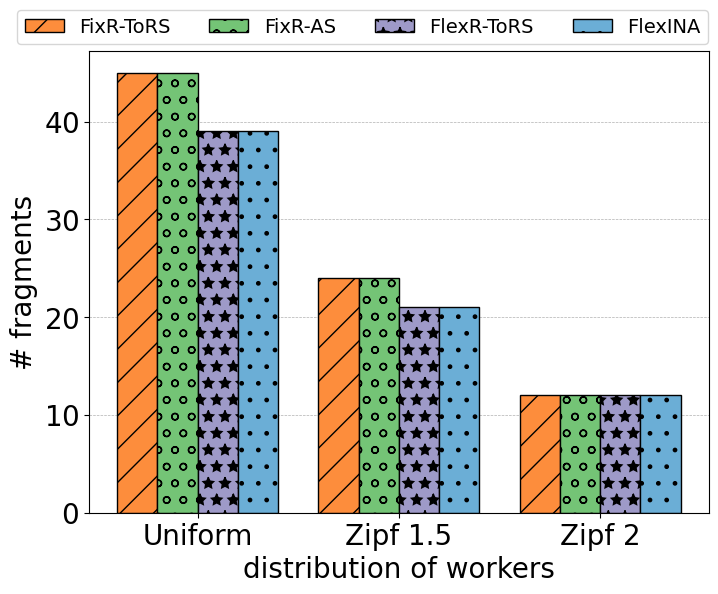

In [99]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['Uniform' , 'Zipf 1.5' , 'Zipf 2']

C_2 = kindsofModelsPackets[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsPackets[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsPackets[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsPackets[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('# fragments')
ax.set_xlabel('distribution of workers')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.11), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
plt.rcParams.update({'font.size': 20})
plt.savefig("Distribution_of_workers_Number_of_Fragments_ittr3.pdf", bbox_inches="tight",format="pdf")
plt.show()


<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
C:\Users\mmdsb\AppData\Local\Temp\ipykernel_7492\2472956691.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('runtime (s, $\log_{10}$ scale)')


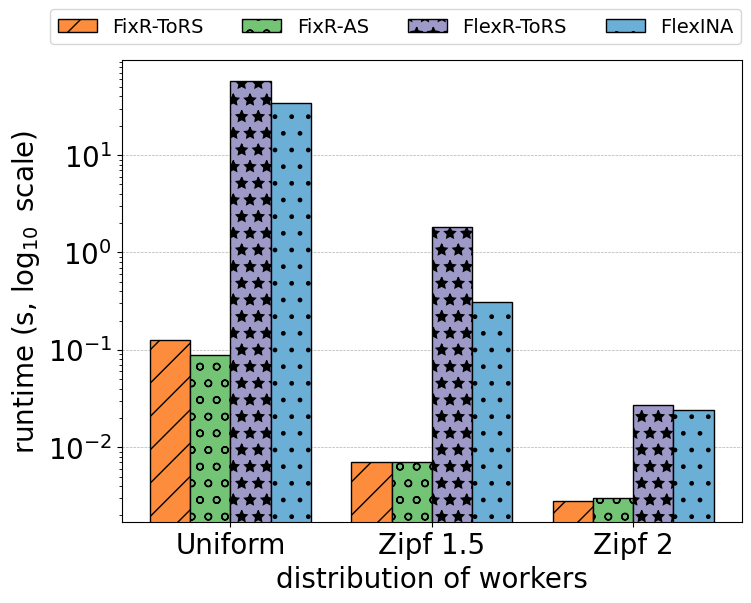

In [100]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker

cmap = sns.color_palette("tab20c")
labels = ['Uniform' , 'Zipf 1.5' , 'Zipf 2']

C_2 = kindsofModelsRuntime[defineModel_ATP]  # FixR-ToRS
C_3 = kindsofModelsRuntime[defineModel_GRID]  # FixR-AS
C_4 = kindsofModelsRuntime[defineModel_ATP_GRID]  # FlexR-ToRS
C_5 = kindsofModelsRuntime[defineModel_selectedSwitches]  # FlexINA

x = np.arange(len(labels))  # موقعیت‌های برچسب‌ها روی محور x
width = 0.2  # عرض میله‌ها

hatches = ['/', 'o', '*', '.']

fig, ax = plt.subplots(figsize=(8, 6))

rects1 = ax.bar(x - 1.5 * width, C_2, width, label='FixR-ToRS', color=cmap[5], hatch=hatches[0])
rects2 = ax.bar(x - 0.5 * width, C_3, width, label='FixR-AS', color=cmap[9], hatch=hatches[1])
rects3 = ax.bar(x + 0.5 * width, C_4, width, label='FlexR-ToRS', color=cmap[13], hatch=hatches[2])
rects4 = ax.bar(x + 1.5 * width, C_5, width, label='FlexINA', color=cmap[1], hatch=hatches[3])

for rect in [rects1, rects2, rects3, rects4]:
    for r in rect:
        r.set_edgecolor('black')

ax.set_ylabel('runtime (s, $\log_{10}$ scale)')
ax.set_xlabel('distribution of workers')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
legend = ax.legend(loc= 1, bbox_to_anchor=(1.015, 1.13), ncol=5,prop={'size': 14})
'''
def autolabel(rects):
    """اضافه کردن مقدار عددی بالای هر میله."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # فاصله از بالا
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
'''
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2)) 
ax.yaxis.set_major_formatter(formatter)

plt.grid(axis='y', linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)
ax.set_yscale('log')
plt.rcParams.update({'font.size': 20})
plt.savefig("Distribution_of_workers_Runtime_ittr3.pdf", bbox_inches="tight",format="pdf")
plt.show()


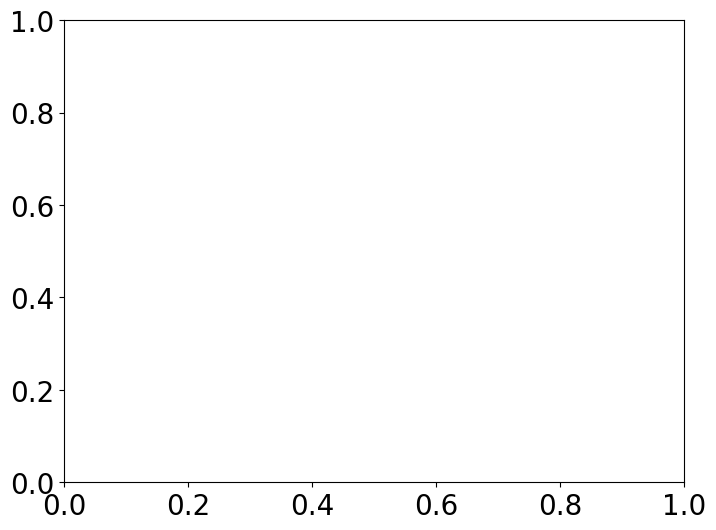

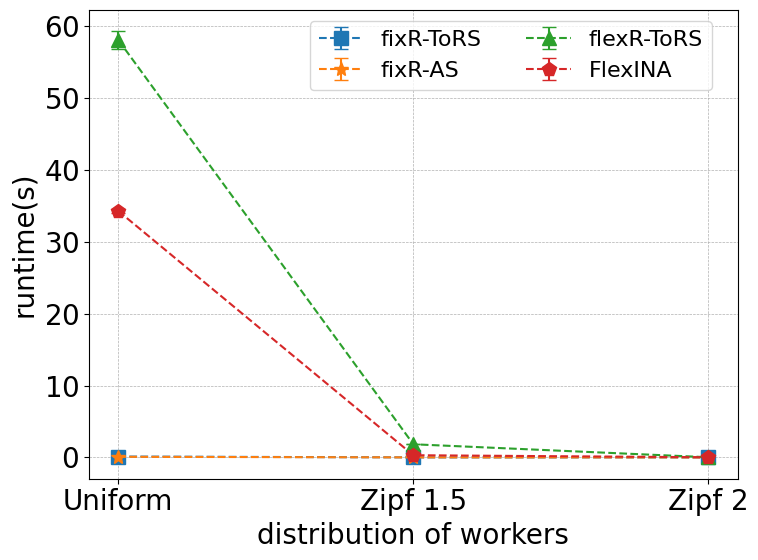

In [101]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
Kinds_of_Dependency = ['Uniform' , 'Zipf 1.5' , 'Zipf 2']

fig, ax = plt.subplots(figsize=(8, 6))


y2 = kindsofModelsRuntime[defineModel_ATP]
y3 = kindsofModelsRuntime[defineModel_GRID]
y4 = kindsofModelsRuntime[defineModel_ATP_GRID]
y5 = kindsofModelsRuntime[defineModel_selectedSwitches]
error_y2 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP]]
error_y3 = [np.std(vals) for vals in errorRuntimesM[defineModel_GRID]]
error_y4 = [np.std(vals) for vals in errorRuntimesM[defineModel_ATP_GRID]]
error_y5 = [np.std(vals) for vals in errorRuntimesM[defineModel_selectedSwitches]]

# ترسیم نمودار با error bar
fig, ax = plt.subplots(figsize=(8, 6))
x = Kinds_of_Dependency
plt.errorbar(x, y2, yerr=error_y2, fmt='s--', markersize=10, capsize=5, label='fixR-ToRS')
plt.errorbar(x, y3, yerr=error_y3, fmt='*--', markersize=10, capsize=5, label='fixR-AS')
plt.errorbar(x, y4, yerr=error_y4, fmt='^--', markersize=10, capsize=5, label='flexR-ToRS')
plt.errorbar(x, y5, yerr=error_y5, fmt='p--', markersize=10, capsize=5, label='FlexINA')
x2 = Kinds_of_Dependency
x3 = Kinds_of_Dependency
x4 = Kinds_of_Dependency
x5 = Kinds_of_Dependency


#plt.plot(x2, y2,ls = 'dashed',marker = 's',markersize=10,label='fixR-ToRS')
#plt.plot(x3, y3,ls = 'dashed',marker = '*',markersize=10,label='fixR-AS')
#plt.plot(x4, y4,ls = 'dashed',marker = '^',markersize=10,label='flexR-ToRS')
#plt.plot(x5, y5,ls = 'dashed',marker = 'p',markersize=10,label='FlexINA')

plt.legend(loc='upper center', bbox_to_anchor=(0.65, 1), ncol=2 ,prop={'size': 16} )
plt.xlabel('distribution of workers')
plt.ylabel('runtime(s)')
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-3, 3))  # Adjust the power limits as needed
ax.yaxis.set_major_formatter(formatter)
fig.tight_layout()
plt.grid(linestyle = '--', linewidth = 0.5)
plt.rcParams.update({'font.size': 22})
plt.savefig( "Distribution_of_workers_Runtime_itt3_New.pdf", bbox_inches="tight", format="pdf")
plt.show()